# Proyecto Clasificacion de Series de Tiempo enfocado en Curvas de Luz

### Datos y características utilizadas.


In [ ]:
from google.colab import files

# Subir archivos del computador
uploaded = files.upload()


Saving plasticc_train_lightcurves.csv to plasticc_train_lightcurves.csv
Saving plasticc_train_metadata.csv to plasticc_train_metadata.csv
Saving plasticc_train_target_names.csv to plasticc_train_target_names.csv


In [ ]:
import pandas as pd

meta = pd.read_csv("plasticc_train_metadata.csv")
targets = pd.read_csv("plasticc_train_target_names.csv")
lightcurves = pd.read_csv("plasticc_train_lightcurves.csv")

print("✅ Archivos cargados correctamente.\n")
print("=== Metadata ===")
display(meta.head())

print("=== Target Names ===")
display(targets.head())

print("=== Lightcurves ===")
display(lightcurves.head())



✅ Archivos cargados correctamente.

=== Metadata ===


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
0,615,349.0461,-61.9438,1,0.000,0.000,0.000,-9.000,0.017,92,...,0.0,0.0,59570.000,69,484.7,3286.7,3214.1,3039.7,2854.5,2837.0
1,713,53.0859,-27.7844,1,1.818,1.627,0.255,45.406,0.007,88,...,0.0,0.0,59570.000,34,108.7,117.7,119.9,149.6,147.9,150.5
2,730,33.5742,-6.5796,1,0.232,0.226,0.016,40.256,0.021,42,...,0.0,0.0,60444.379,9,0.0,0.0,0.0,0.0,0.0,0.0
3,745,0.1899,-45.5867,1,0.304,0.281,1.152,40.795,0.007,90,...,0.0,0.0,60130.453,38,0.0,0.0,0.0,0.0,0.0,0.0
4,1124,352.7113,-63.8237,1,0.193,0.241,0.018,40.417,0.024,90,...,0.0,0.0,60452.641,1,0.0,0.0,0.0,0.0,0.0,0.0


=== Target Names ===


,target,type
0,6,uLens-Single_GenLens
1,15,TDE
2,16,EB
3,42,SNIIn
4,52,SNIax


=== Lightcurves ===


,object_id,mjd,passband,flux,flux_err,detected_bool
0,615,59750.4229,2,-544.810303,3.622952,1
1,615,59750.4306,1,-816.434326,5.553370,1
2,615,59750.4383,3,-471.385529,3.801213,1
3,615,59750.4450,4,-388.984985,11.395031,1
4,615,59752.4070,2,-681.858887,4.041204,1


In [ ]:
# --- Mostrar información general ---
print("=== plasticc_train_metadata.csv ===")
print(f"Número de columnas: {meta.shape[1]}")
print("Nombres de columnas:", list(meta.columns))
print("\n")

print("=== plasticc_train_target_names.csv ===")
print(f"Número de columnas: {targets.shape[1]}")
print("Nombres de columnas:", list(targets.columns))
print("\n")

print("=== plasticc_train_lightcurves.csv ===")
print(f"Número de columnas: {lightcurves.shape[1]}")
print("Nombres de columnas:", list(lightcurves.columns))

=== plasticc_train_metadata.csv ===
Número de columnas: 26
Nombres de columnas: ['object_id', 'ra', 'decl', 'ddf_bool', 'hostgal_specz', 'hostgal_photoz', 'hostgal_photoz_err', 'distmod', 'mwebv', 'target', 'true_target', 'true_submodel', 'true_z', 'true_distmod', 'true_lensdmu', 'true_vpec', 'true_rv', 'true_av', 'true_peakmjd', 'libid_cadence', 'tflux_u', 'tflux_g', 'tflux_r', 'tflux_i', 'tflux_z', 'tflux_y']


=== plasticc_train_target_names.csv ===
Número de columnas: 2
Nombres de columnas: ['target', ' type']


=== plasticc_train_lightcurves.csv ===
Número de columnas: 6
Nombres de columnas: ['object_id', 'mjd', 'passband', 'flux', 'flux_err', 'detected_bool']


### Preprocesamiento de datos

In [ ]:
# --- Unir metadatos con nombres de clase ---
# Une el código de clase (target) con su nombre legible
meta_named = meta.merge(targets, on="target", how="left")

print(meta_named.shape)
meta_named.head()

# -> Agrega una columna con el nombre humano de la clase, ej: SNIIn, AGN.

(7848, 27)


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y,type
0,615,349.0461,-61.9438,1,0.000,0.000,0.000,-9.000,0.017,92,...,0.0,59570.000,69,484.7,3286.7,3214.1,3039.7,2854.5,2837.0,RRL
1,713,53.0859,-27.7844,1,1.818,1.627,0.255,45.406,0.007,88,...,0.0,59570.000,34,108.7,117.7,119.9,149.6,147.9,150.5,AGN
2,730,33.5742,-6.5796,1,0.232,0.226,0.016,40.256,0.021,42,...,0.0,60444.379,9,0.0,0.0,0.0,0.0,0.0,0.0,SNIIn
3,745,0.1899,-45.5867,1,0.304,0.281,1.152,40.795,0.007,90,...,0.0,60130.453,38,0.0,0.0,0.0,0.0,0.0,0.0,SNIa
4,1124,352.7113,-63.8237,1,0.193,0.241,0.018,40.417,0.024,90,...,0.0,60452.641,1,0.0,0.0,0.0,0.0,0.0,0.0,SNIa


In [ ]:
#--- Chequeo y tipado de columnas útiles ---

import numpy as np

# Copia para trabajar
lc = lightcurves.copy()

# Tipos más compactos
lc["object_id"]   = lc["object_id"].astype(np.int64)
lc["passband"]    = lc["passband"].astype("int8")
lc["detected_bool"]= lc["detected_bool"].astype("int8")
for col in ["mjd","flux","flux_err"]:
    lc[col] = pd.to_numeric(lc[col], errors="coerce")

# Mapea passband numérico a etiqueta (0–5 -> u,g,r,i,z,y)
band_map = {0:"u", 1:"g", 2:"r", 3:"i", 4:"z", 5:"y"}
lc["band"] = lc["passband"].map(band_map).astype("category")

# Vista rápida
print(lc.dtypes)
lc.head()

# -> Asegura types, crea bandas legibles y prepara dataframe.


object_id           int64
mjd               float64
passband             int8
flux              float64
flux_err          float64
detected_bool        int8
band             category
dtype: object


,object_id,mjd,passband,flux,flux_err,detected_bool,band
0,615,59750.4229,2,-544.810303,3.622952,1,r
1,615,59750.4306,1,-816.434326,5.553370,1,g
2,615,59750.4383,3,-471.385529,3.801213,1,i
3,615,59750.4450,4,-388.984985,11.395031,1,z
4,615,59752.4070,2,-681.858887,4.041204,1,r


In [ ]:
#--- Limpieza datos (estilo ALeRCE)  ---


# 3.1 Elimina filas sin información numérica
lc = lc.dropna(subset=["mjd", "flux", "flux_err"])

# 3.2 Descarta mediciones con error no físico
lc = lc[lc["flux_err"] > 0]

# 3.3 Crea SNR (señal/ruido) y marca detecciones “útiles”
lc["snr"] = lc["flux"].abs() / lc["flux_err"]

# filtra detecciones débiles
MIN_SNR = 3.0
lc_det = lc[(lc["detected_bool"] == 1) & (lc["snr"] >= MIN_SNR)].copy()

print("Total observaciones (todas):", len(lc))
print("Observaciones detectadas y SNR>=3:", len(lc_det))




Total observaciones (todas): 1421705
Observaciones detectadas y SNR>=3: 235832


In [ ]:
#--- Requisito de datos mínimos por objeto (>= 50 detecciones) ---

MIN_DET_PER_OBJ = 50

det_counts = lc_det.groupby("object_id").size().rename("n_det")
eligible_ids = det_counts[det_counts >= MIN_DET_PER_OBJ].index

lc_det_elig = lc_det[lc_det["object_id"].isin(eligible_ids)].copy()

print("Objetos elegibles:", lc_det_elig["object_id"].nunique())
lc_det_elig.head()


# -> Nos quedamos con objetos que tengan suficientes detecciones para extraer características fiables.


Objetos elegibles: 1356


,object_id,mjd,passband,flux,flux_err,detected_bool,band,snr
0,615,59750.4229,2,-544.810303,3.622952,1,r,150.377455
1,615,59750.4306,1,-816.434326,5.553370,1,g,147.016015
2,615,59750.4383,3,-471.385529,3.801213,1,i,124.009238
3,615,59750.4450,4,-388.984985,11.395031,1,z,34.136369
4,615,59752.4070,2,-681.858887,4.041204,1,r,168.726668


In [ ]:
# --- Remoción robusta de ooutliers por objeto ---


# Cálculos por grupo (object_id, band)
grp = lc_det_elig.groupby(["object_id", "band"])

# Mediana y MAD (Median Absolute Deviation)
med = grp["flux"].transform("median")
mad = (grp["flux"].transform(lambda x: (x - x.median()).abs().median()) + 1e-9)

robust_z = (lc_det_elig["flux"] - med) / (1.4826 * mad)  # 1.4826 ~ convertir MAD a sigma

# Umbral de outlier robusto
ZMAX = 5
mask_inlier = robust_z.abs() <= ZMAX
lc_clean = lc_det_elig[mask_inlier].copy()

print("Observaciones removidas por outliers:", (~mask_inlier).sum())
lc_clean.head()


# -> Elimina mediciones extremas por cada curva de luz en cada banda sin asumir normalidad.

/tmp/ipython-input-4092468777.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = lc_det_elig.groupby(["object_id", "band"])


Observaciones removidas por outliers: 5838


,object_id,mjd,passband,flux,flux_err,detected_bool,band,snr
0,615,59750.4229,2,-544.810303,3.622952,1,r,150.377455
1,615,59750.4306,1,-816.434326,5.553370,1,g,147.016015
2,615,59750.4383,3,-471.385529,3.801213,1,i,124.009238
3,615,59750.4450,4,-388.984985,11.395031,1,z,34.136369
4,615,59752.4070,2,-681.858887,4.041204,1,r,168.726668


In [ ]:
#--- Resumen por objeto y por banda (bases de los features) ---

# Conteos por objeto/banda
per_band = (lc_clean
            .groupby(["object_id","band"])
            .agg(n_det=("flux","size"),
                 snr_med=("snr","median"),
                 flux_med=("flux","median"),
                 flux_mean=("flux","mean"),
                 flux_std=("flux","std"),
                 flux_p05=("flux",lambda x: x.quantile(0.05)),
                 flux_p95=("flux",lambda x: x.quantile(0.95)))
            .reset_index())

# Amplitud robusta por banda (p95 - p05)
per_band["amp_rob"] = per_band["flux_p95"] - per_band["flux_p05"]

# Resumen por objeto (agregando sobre bandas)
per_obj = (per_band
           .groupby("object_id")
           .agg(bands_obs=("band","nunique"),
                n_det_total=("n_det","sum"),
                amp_rob_sum=("amp_rob","sum"),
                snr_med_med=("snr_med","median"))
           .reset_index())

print(per_band.head())
print(per_obj.head())

# -> Base para la ing. de características.

/tmp/ipython-input-1659662205.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["object_id","band"])


   object_id band  n_det     snr_med    flux_med   flux_mean    flux_std  \
0        615    g     56  132.138542 -532.094818 -399.145260  608.242211   
1        615    i     57  108.846913 -176.163651 -123.153241  338.039994   
2        615    r     57  137.696272 -274.711029 -136.581699  458.785584   
3        615    u     54   24.617528  -32.957119   -3.930640   90.650537   
4        615    y     52   39.118873 -152.416489  -53.526884  308.126991   

      flux_p05    flux_p95      amp_rob  
0 -1088.590179  652.059250  1740.649429  
1  -519.744507  376.572705   896.317213  
2  -676.944494  600.718665  1277.663159  
3  -113.432905  120.855450   234.288354  
4  -416.867760  370.323724   787.191484  
   object_id  bands_obs  n_det_total  amp_rob_sum  snr_med_med
0        615          6          333  5716.297011    94.527187
1        713          6           51    51.486828     6.980765
2        745          6           56   325.595996    11.376369
3       1124          6           56   

In [ ]:
#--- Nombre de las columnas ---

print(meta_named.columns)


Index(['object_id', 'ra', 'decl', 'ddf_bool', 'hostgal_specz',
       'hostgal_photoz', 'hostgal_photoz_err', 'distmod', 'mwebv', 'target',
       'true_target', 'true_submodel', 'true_z', 'true_distmod',
       'true_lensdmu', 'true_vpec', 'true_rv', 'true_av', 'true_peakmjd',
       'libid_cadence', 'tflux_u', 'tflux_g', 'tflux_r', 'tflux_i', 'tflux_z',
       'tflux_y', ' type'],
      dtype='object')


In [ ]:
# --> Elimina espacios en los nombres de columna
meta_named.columns = meta_named.columns.str.strip()

# Columnas de metadatos que queremos incluir
meta_cols = [
    "object_id", "target", "type",
    "ddf_bool", "hostgal_photoz", "hostgal_photoz_err",
    "mwebv", "distmod",
    "tflux_u", "tflux_g", "tflux_r", "tflux_i", "tflux_z", "tflux_y"
]

# --> Junta el resumen por objeto con metadatos y nombre de clase
dataset = (per_obj
    .merge(meta_named[meta_cols], on="object_id", how="left"))

# -> Nuevas features: "colores" de flujo
dataset["tflux_u_g"] = dataset["tflux_u"] - dataset["tflux_g"]
dataset["tflux_g_r"] = dataset["tflux_g"] - dataset["tflux_r"]
print(dataset.shape)
dataset.head()


(1356, 20)


,object_id,bands_obs,n_det_total,amp_rob_sum,snr_med_med,target,type,ddf_bool,hostgal_photoz,hostgal_photoz_err,mwebv,distmod,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y,tflux_u_g,tflux_g_r
0,615,6,333,5716.297011,94.527187,92,RRL,1,0.000,0.000,0.017,-9.000,484.7,3286.7,3214.1,3039.7,2854.5,2837.0,-2802.0,72.6
1,713,6,51,51.486828,6.980765,88,AGN,1,1.627,0.255,0.007,45.406,108.7,117.7,119.9,149.6,147.9,150.5,-9.0,-2.2
2,745,6,56,325.595996,11.376369,90,SNIa,1,0.281,1.152,0.007,40.795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1124,6,56,295.934710,10.453548,90,SNIa,1,0.241,0.018,0.024,40.417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1920,6,55,869.106203,35.938660,90,SNIa,1,0.323,0.336,0.027,41.140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Limpiar espacios en blanco en la columna de clase
dataset["type"] = dataset["type"].astype(str).str.strip()

print("Clases después de strip():")
print(dataset["type"].unique())


Clases después de strip():
['RRL' 'AGN' 'SNIa' 'EB' 'SNIa-91bg' 'TDE' 'SNIIn' 'SLSN' 'SNIax' 'SNIbc'
 'uLens-Single_GenLens' 'Mdwarf' 'MIRA']


In [ ]:
print("\nClases antes de filtrar uLens:")
print(dataset["type"].value_counts())

dataset = dataset[dataset["type"] != "uLens-Single_GenLens"].copy()

print("\nClases después de filtrar uLens:")
print(dataset["type"].value_counts())



Clases antes de filtrar uLens:
type
EB                      262
SNIa                    244
AGN                     233
RRL                     232
SNIIn                   129
Mdwarf                   62
SNIbc                    45
SLSN                     38
uLens-Single_GenLens     35
MIRA                     30
SNIax                    26
SNIa-91bg                13
TDE                       7
Name: count, dtype: int64

Clases después de filtrar uLens:
type
EB           262
SNIa         244
AGN          233
RRL          232
SNIIn        129
Mdwarf        62
SNIbc         45
SLSN          38
MIRA          30
SNIax         26
SNIa-91bg     13
TDE            7
Name: count, dtype: int64


Objetos después de filtros de calidad: 795
Total de objetos en el dataset: 795
Total de observaciones (todas las bandas combinadas): 151,235

=== Distribución de clases ===


,class_name,n_objects,percent
0,EB,244,30.691824
1,RRL,232,29.182390
2,AGN,230,28.930818
3,Mdwarf,59,7.421384
4,MIRA,30,3.773585


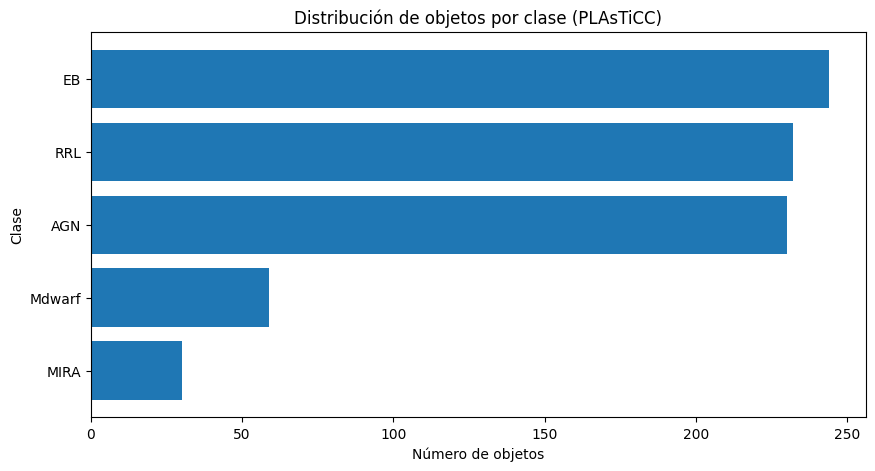

In [ ]:
# --- Filtros de calidad ---

# 1) Mínimo de detecciones totales por objeto
MIN_DET_TOTAL = 50

mask_det = dataset["n_det_total"] >= MIN_DET_TOTAL

# 2) Flux total positivo en todas las bandas
flux_cols = ["tflux_u", "tflux_g", "tflux_r", "tflux_i", "tflux_z", "tflux_y"]

mask_flux = (dataset[flux_cols] > 0).all(axis=1)


# 3) Clases que utilizaremos

clases_permitidas = [
    "EB",
    "RRL",
    "AGN",
    "Mdwarf",
    "MIRA"
]
mask_class = dataset["type"].isin(clases_permitidas)

# 4) Aplicamos ambos filtros a la vez
dataset = dataset[mask_det & mask_flux].reset_index(drop=True)

print("Objetos después de filtros de calidad:",
      dataset["object_id"].nunique())



# --- Resumen general ---
print(f"Total de objetos en el dataset: {dataset['object_id'].nunique()}")
print(f"Total de observaciones (todas las bandas combinadas): {len(lc_clean):,}\n")

# --- Conteo de clases ---
class_counts = dataset['type'].value_counts().rename_axis('class_name').reset_index(name='n_objects')
class_counts['percent'] = 100 * class_counts['n_objects'] / class_counts['n_objects'].sum()

print("=== Distribución de clases ===")
display(class_counts)

# --- Gráfico rápido de barras ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(class_counts['class_name'], class_counts['n_objects'])
plt.xlabel('Número de objetos')
plt.ylabel('Clase')
plt.title('Distribución de objetos por clase (PLAsTiCC)')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
print(dataset['type'].unique())
print(dataset['type'].value_counts())


['RRL' 'AGN' 'EB' 'Mdwarf' 'MIRA']
type
EB        244
RRL       232
AGN       230
Mdwarf     59
MIRA       30
Name: count, dtype: int64


In [ ]:
# Promedios globales de features básicas
stats = dataset[['n_det_total', 'bands_obs', 'amp_rob_sum', 'snr_med_med']].describe()
print("=== Estadísticos generales de las curvas limpias ===")
display(stats)


=== Estadísticos generales de las curvas limpias ===


,n_det_total,bands_obs,amp_rob_sum,snr_med_med
count,795.000000,795.0,795.000000,795.000000
mean,141.405031,6.0,12586.968991,36.544417
std,89.217686,0.0,24358.429261,40.882748
min,50.000000,6.0,9.720070,5.551360
25%,73.000000,6.0,449.173808,12.058804
50%,110.000000,6.0,1634.996760,19.456558
75%,185.000000,6.0,16867.733979,39.515818
max,352.000000,6.0,333624.740048,204.636327


In [ ]:
print(f"Número total de características (columnas): {dataset.shape[1]}")
print("Nombres de las columnas:")
print(list(dataset.columns))


# Hasta aquí tenemos 11 features y queremos reducir a (5-6)

Número total de características (columnas): 20
Nombres de las columnas:
['object_id', 'bands_obs', 'n_det_total', 'amp_rob_sum', 'snr_med_med', 'target', 'type', 'ddf_bool', 'hostgal_photoz', 'hostgal_photoz_err', 'mwebv', 'distmod', 'tflux_u', 'tflux_g', 'tflux_r', 'tflux_i', 'tflux_z', 'tflux_y', 'tflux_u_g', 'tflux_g_r']


### Reducción de features a utilizar

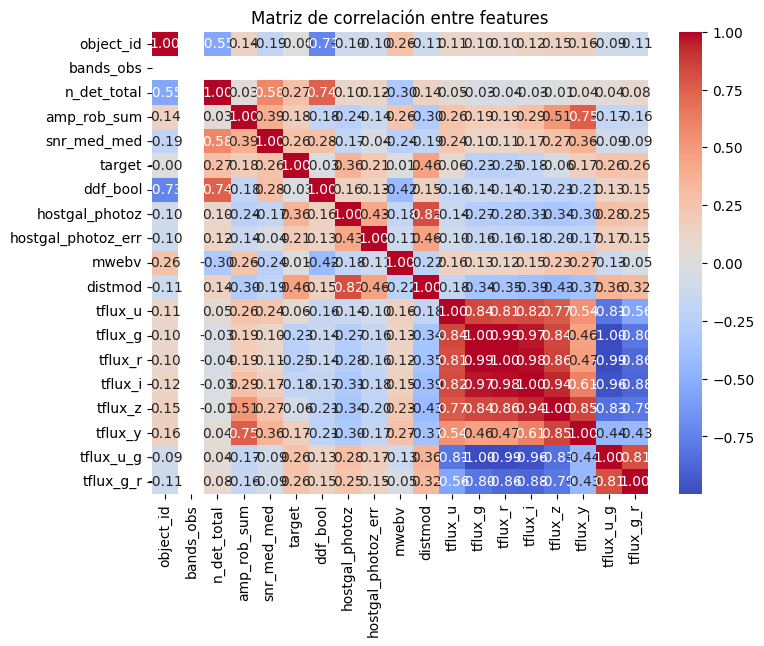

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcula correlaciones solo entre variables numéricas
corr = dataset.select_dtypes(include=['float64','int64']).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación entre features")
plt.show()


In [ ]:
features_finales = [
    'n_det_total',        # número total de detecciones
    'amp_rob_sum',        # amplitud total (variabilidad)
    'snr_med_med',        # señal/ruido mediana
    'hostgal_photoz',     # redshift (distancia)
    'mwebv',              # extinción por polvo interestelar
    'ddf_bool'            # tipo de campo observado (profundidad)
    # Nuevas features exigidas:
    'tflux_u_g',       # color u - g
    'tflux_g_r'        # color g - r
    ]


### Estandarización de clases / normalización

In [ ]:
from sklearn.model_selection import train_test_split

#--- Preparación de datos ---


# Features seleccionadas
features_finales = [
    'n_det_total',    # número total de detecciones
    'amp_rob_sum',    # amplitud total (variabilidad)
    'snr_med_med',    # señal/ruido mediana
    'hostgal_photoz', # redshift fotométrico
    'mwebv',          # extinción por polvo interestelar
    'ddf_bool',       # tipo de campo observado (profundidad)
    'tflux_u_g',      # NUEVO: color de flujo u-g
    'tflux_g_r'       # NUEVO: color de flujo g-r
]

X = dataset[features_finales].copy()
y = dataset['target']

# Separar train/valid (por ejemplo, 80/20)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}")

# -> Conjunto entrenamiento y vaidación


Train: (636, 8), Valid: (159, 8)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

#--- Normalización Min-Max (0-1)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


In [ ]:
#--- Visualización de los datos normalizados ---

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_finales, index=X_train.index)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=features_finales, index=X_valid.index)

print("=== Muestras normalizadas (primeras filas) ===")
display(X_train_scaled.head())


=== Muestras normalizadas (primeras filas) ===


,n_det_total,amp_rob_sum,snr_med_med,hostgal_photoz,mwebv,ddf_bool,tflux_u_g,tflux_g_r
537,0.145695,0.017201,0.118891,0.000000,0.074615,0.0,0.988423,0.836385
485,0.009934,0.004632,0.023872,0.000000,0.227899,0.0,0.950709,0.796469
464,0.043046,0.000233,0.016043,0.000000,0.059205,0.0,0.998045,0.843132
34,0.364238,0.004659,0.067629,0.472523,0.008921,1.0,0.995821,0.839489
502,0.298013,0.047407,0.310743,0.135936,0.012976,0.0,0.986620,0.843682


### Random Forest

Targets usados en matriz de confusión: [np.int64(16), np.int64(53), np.int64(65), np.int64(88), np.int64(92)]
Nombres de clases en ese orden: ['EB', 'MIRA', 'Mdwarf', 'AGN', 'RRL']
=== Random Forest: Accuracy ===
Train      : 1.0000
Validación : 0.9748


=== Random Forest: Métricas adicionales ===
F1-macro          : 0.9474
Balanced Accuracy : 0.9249


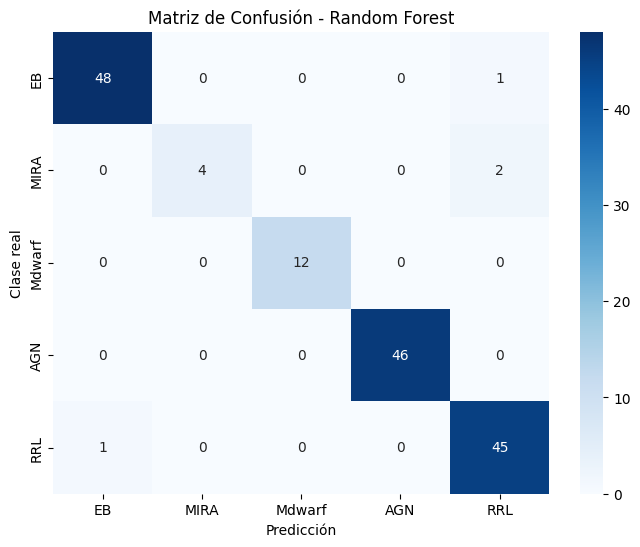

In [ ]:
# === RANDOM FOREST: accuracy train/valid + matriz de confusión ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- Mapeo target numérico -> nombre de clase ('type') ---
label_map = (dataset[['target', 'type']]
             .drop_duplicates()
             .set_index('target')['type']
             .to_dict())

# --- Orden de clases basado en los códigos target (mismo para RF y CNN) ---
class_targets = sorted(dataset['target'].unique())
class_names   = [label_map[t] for t in class_targets]

print("Targets usados en matriz de confusión:", class_targets)
print("Nombres de clases en ese orden:", class_names)

# --- Modelo Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
rf.fit(X_train_scaled, y_train)

# Predicciones
y_pred_train = rf.predict(X_train_scaled)
y_pred_valid = rf.predict(X_valid_scaled)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_valid = accuracy_score(y_valid, y_pred_valid)

print("=== Random Forest: Accuracy ===")
print(f"Train      : {acc_train:.4f}")
print(f"Validación : {acc_valid:.4f}\n")

# ==== MÉTRICAS ADICIONALES ====
f1_macro = f1_score(y_valid, y_pred_valid, average='macro')
bal_acc  = balanced_accuracy_score(y_valid, y_pred_valid)
print("\n=== Random Forest: Métricas adicionales ===")
print(f"F1-macro          : {f1_macro:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")

# --- Matriz de confusión en espacio de targets numéricos ---
cm_rf = confusion_matrix(
    y_valid,
    y_pred_valid,
    labels=class_targets   # MISMO orden para RF y CNN
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()



=== Random Forest (21 corridas) ===
Accuracy promedio       : 0.9748 ± 0.0000
F1-macro promedio       : 0.9474 ± 0.0000
Balanced Accuracy prom. : 0.9249 ± 0.0000


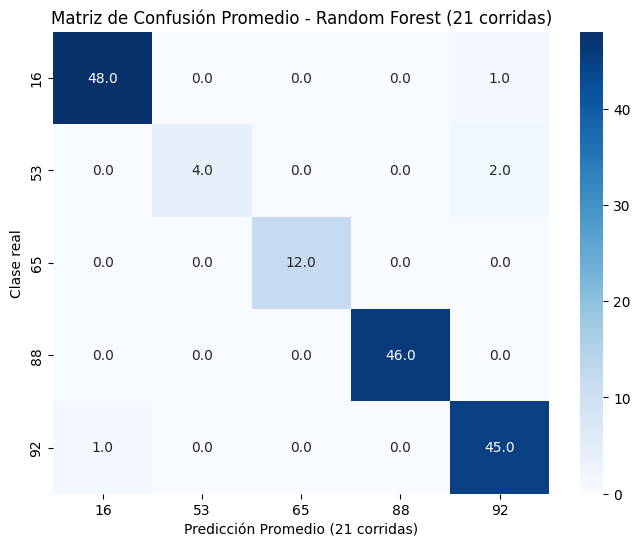

In [ ]:

# ===============================================================
#     RANDOM FOREST REPETIDO 21 VECES (para métricas estables)
# ===============================================================

N_RUNS = 21

acc_list = []
f1_list = []
balacc_list = []
cms = []   # matrices de confusión

seeds = np.arange(1, N_RUNS + 1)

for seed in seeds:

    rf_tmp = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=seed,   # <-- cambia en cada corrida
        n_jobs=-1
    )

    # Entrenar
    rf_tmp.fit(X_train_scaled, y_train)

    # Predicciones
    y_pred = rf_tmp.predict(X_valid_scaled)

    # Métricas
    acc = accuracy_score(y_valid, y_pred)
    f1m = f1_score(y_valid, y_pred, average='macro')
    balacc = balanced_accuracy_score(y_valid, y_pred)

    acc_list.append(acc)
    f1_list.append(f1m)
    balacc_list.append(balacc)

    # Matriz de confusión
    cm = confusion_matrix(
        y_valid,
        y_pred,
        labels=class_targets
    )
    cms.append(cm)


# ===============================================================
#     RESULTADOS PROMEDIO + DESVIACIÓN ESTÁNDAR
# ===============================================================

print("\n=== Random Forest (21 corridas) ===")
print(f"Accuracy promedio       : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"F1-macro promedio       : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"Balanced Accuracy prom. : {np.mean(balacc_list):.4f} ± {np.std(balacc_list):.4f}")

# ===============================================================
#     MATRIZ DE CONFUSIÓN PROMEDIO
# ===============================================================
cm_mean = np.mean(cms, axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(cm_mean, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción Promedio (21 corridas)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión Promedio - Random Forest (21 corridas)")
plt.show()


### CNN

Clases del LabelEncoder (targets): [16 53 65 88 92]
Pesos de clase (CNN): {0: np.float64(0.6523076923076923), 1: np.float64(5.3), 2: np.float64(2.706382978723404), 3: np.float64(0.691304347826087), 4: np.float64(0.6838709677419355)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 278ms/step - accuracy: 0.3885 - loss: 1.5339 - val_accuracy: 0.2893 - val_loss: 1.5973
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4552 - loss: 1.2365 - val_accuracy: 0.2893 - val_loss: 1.5766
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5722 - loss: 1.0008 - val_accuracy: 0.2893 - val_loss: 1.5531
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6335 - loss: 0.9006 - val_accuracy: 0.2893 - val_loss: 1.5318
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6162 - loss: 0.8686 - val_accuracy: 0.2893 - val_loss: 1.5214
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6504 - loss: 0.7107 - val_accuracy: 0.2893 - val_loss: 1.4898
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6967 - loss: 0.6633 - val_accuracy: 0.2893 - val_loss: 1.4397
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6841 - loss: 0.7030 - val_accuracy: 0.2956 

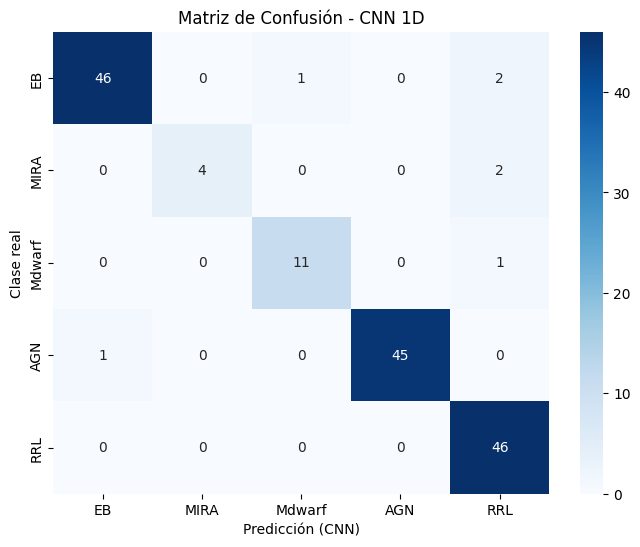

In [ ]:
# === CNN 1D: accuracy train/valid + matriz de confusión alineada ===
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, balanced_accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# --- Preparar X para CNN (shape: samples, features, 1) ---
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_arr = X_train_scaled.values
else:
    X_train_arr = X_train_scaled

if isinstance(X_valid_scaled, pd.DataFrame):
    X_valid_arr = X_valid_scaled.values
else:
    X_valid_arr = X_valid_scaled

n_features = X_train_arr.shape[1]
X_train_cnn = X_train_arr.reshape(-1, n_features, 1)
X_valid_cnn = X_valid_arr.reshape(-1, n_features, 1)

# --- Codificar y con LabelEncoder sobre los targets numéricos ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
num_classes = len(le.classes_)

print("Clases del LabelEncoder (targets):", le.classes_)

# --- Pesos de clase para balancear la pérdida ---
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Pesos de clase (CNN):", class_weight_dict)

# --- Definir modelo CNN 1D ---
model = models.Sequential([
    layers.Conv1D(32, kernel_size=3, activation='relu',
                  input_shape=(n_features, 1)),
    layers.BatchNormalization(),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

# --- Entrenamiento ---
history = model.fit(
    X_train_cnn, y_train_enc,
    epochs=200,
    batch_size=32,
    validation_data=(X_valid_cnn, y_valid_enc),
    callbacks=[es],
    class_weight=class_weight_dict,
    verbose=1
)

# --- Evaluación ---
train_loss, train_acc = model.evaluate(X_train_cnn, y_train_enc, verbose=0)
valid_loss, valid_acc = model.evaluate(X_valid_cnn, y_valid_enc, verbose=0)

print("\n=== CNN 1D: Accuracy ===")
print(f"Train      : {train_acc:.4f}")
print(f"Validación : {valid_acc:.4f}")

# --- Predicciones ---
y_pred_prob = model.predict(X_valid_cnn)
y_pred_enc = np.argmax(y_pred_prob, axis=1)

# ==== MÉTRICAS ADICIONALES ====
f1_macro = f1_score(y_valid_enc, y_pred_enc, average='macro')
bal_acc  = balanced_accuracy_score(y_valid_enc, y_pred_enc)
print("\n=== CNN 1D: Métricas adicionales ===")
print(f"F1-macro          : {f1_macro:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")

# --- Matriz de confusión en espacio de targets numéricos ---
# Queremos el MISMO orden de targets que en RF: class_targets
# Pero ahora en el espacio codificado del LabelEncoder:
labels_enc = le.transform(class_targets)

cm_cnn = confusion_matrix(
    y_valid_enc,
    y_pred_enc,
    labels=labels_enc
)

# Ticks con nombres de clase (mismo orden que class_targets)
class_names = [label_map[t] for t in class_targets]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción (CNN)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - CNN 1D")
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz


=== CNN 1D (21 corridas) ===
Accuracy promedio       : 0.9578 ± 0.0087
F1-macro promedio       : 0.9379 ± 0.0129
Balanced Accuracy prom. : 0.9276 ± 0.0192


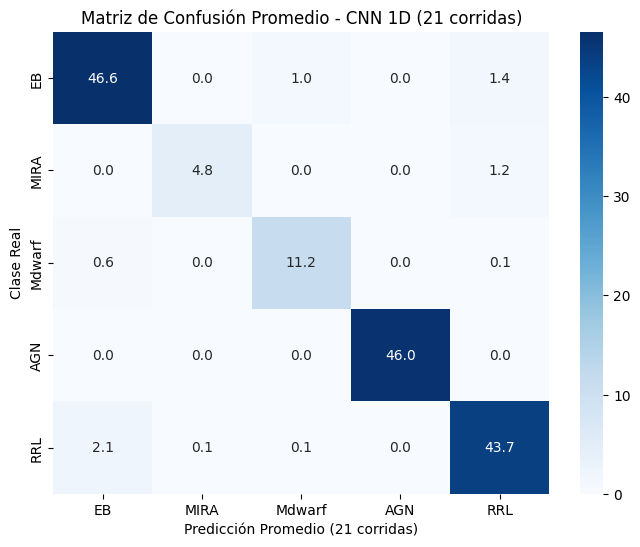

In [ ]:
# =============================================================
#     CNN 1D — 21 corridas con promedios y desviaciones
# =============================================================

N_RUNS = 21

acc_list = []
f1_list = []
balacc_list = []
cms = []

seeds = np.arange(1, N_RUNS + 1)

for seed in seeds:

    # ========== Re-entrenamos el LabelEncoder ==========
    le_tmp = LabelEncoder()
    y_train_enc_tmp = le_tmp.fit_transform(y_train)
    y_valid_enc_tmp = le_tmp.transform(y_valid)
    num_classes_tmp = len(le_tmp.classes_)

    # Reordenar el espacio de clases según RF:
    labels_enc_tmp = le_tmp.transform(class_targets)

    # ========== Re-construir X ==========
    X_train_cnn_tmp = X_train_arr.reshape(-1, n_features, 1)
    X_valid_cnn_tmp = X_valid_arr.reshape(-1, n_features, 1)

    # ========== Re-calcular pesos de clase ==========
    class_weights_array_tmp = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_enc_tmp),
        y=y_train_enc_tmp
    )
    class_weight_dict_tmp = {i: w for i, w in enumerate(class_weights_array_tmp)}

    # ========== Crear CNN ==========
    model_tmp = models.Sequential([
        layers.Conv1D(32, kernel_size=3, activation='relu',
                      input_shape=(n_features, 1)),
        layers.BatchNormalization(),
        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes_tmp, activation='softmax')
    ])

    model_tmp.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    es_tmp = EarlyStopping(
        monitor='val_loss',
        patience=40,
        restore_best_weights=True
    )

    # ========== Entrenar ==========
    model_tmp.fit(
        X_train_cnn_tmp, y_train_enc_tmp,
        epochs=200,
        batch_size=32,
        validation_data=(X_valid_cnn_tmp, y_valid_enc_tmp),
        callbacks=[es_tmp],
        class_weight=class_weight_dict_tmp,
        verbose=0      # <--- ENTRENAMIENTO LIMPIO
    )

    # ========== Evaluar ==========
    y_pred_prob_tmp = model_tmp.predict(X_valid_cnn_tmp, verbose=0)
    y_pred_enc_tmp = np.argmax(y_pred_prob_tmp, axis=1)

    acc = accuracy_score(y_valid_enc_tmp, y_pred_enc_tmp)
    f1m = f1_score(y_valid_enc_tmp, y_pred_enc_tmp, average='macro')
    balacc = balanced_accuracy_score(y_valid_enc_tmp, y_pred_enc_tmp)

    acc_list.append(acc)
    f1_list.append(f1m)
    balacc_list.append(balacc)

    # ========== Matriz de confusión ==========
    cm_tmp = confusion_matrix(
        y_valid_enc_tmp,
        y_pred_enc_tmp,
        labels=labels_enc_tmp
    )
    cms.append(cm_tmp)


# =============================================================
#     RESULTADOS PROMEDIO + DESVIACIONES
# =============================================================

print("\n=== CNN 1D (21 corridas) ===")
print(f"Accuracy promedio       : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"F1-macro promedio       : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"Balanced Accuracy prom. : {np.mean(balacc_list):.4f} ± {np.std(balacc_list):.4f}")

# =============================================================
#     MATRIZ DE CONFUSIÓN PROMEDIO
# =============================================================
cm_mean = np.mean(cms, axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(cm_mean, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=[label_map[t] for t in class_targets],
            yticklabels=[label_map[t] for t in class_targets])
plt.xlabel("Predicción Promedio (21 corridas)")
plt.ylabel("Clase Real")
plt.title("Matriz de Confusión Promedio - CNN 1D (21 corridas)")
plt.show()


### GMM

Targets usados: [np.int64(16), np.int64(53), np.int64(65), np.int64(88), np.int64(92)]
Nombres de clase: ['EB', 'MIRA', 'Mdwarf', 'AGN', 'RRL']
Entrenando GMM para clase 16 (EB), n=195
Entrenando GMM para clase 53 (MIRA), n=24
Entrenando GMM para clase 65 (Mdwarf), n=47
Entrenando GMM para clase 88 (AGN), n=184
Entrenando GMM para clase 92 (RRL), n=186

=== GMM: Accuracy ===
Train      : 0.9292
Validación : 0.9560

=== GMM: Métricas adicionales ===
F1-macro          : 0.9497
Balanced Accuracy : 0.9714


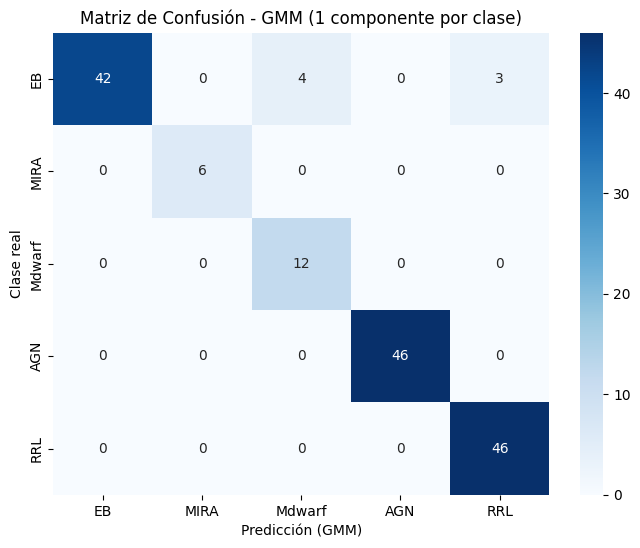

In [ ]:
# === CLASIFICADOR GMM (Gaussian Mixture Model) ===
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, balanced_accuracy_score
# ------------------------------------------------------------------
# 1. Preparar datos y orden de clases (igual que en RF/CNN)
# ------------------------------------------------------------------

# Aseguramos arrays
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_arr = X_train_scaled.values
else:
    X_train_arr = X_train_scaled

if isinstance(X_valid_scaled, pd.DataFrame):
    X_valid_arr = X_valid_scaled.values
else:
    X_valid_arr = X_valid_scaled

# Mapeo target -> nombre de clase
label_map = (dataset[['target', 'type']]
             .drop_duplicates()
             .set_index('target')['type']
             .to_dict())

# Orden de clases basado en los códigos de target
class_targets = sorted(dataset['target'].unique())
class_names   = [label_map[t] for t in class_targets]
n_classes = len(class_targets)

print("Targets usados:", class_targets)
print("Nombres de clase:", class_names)

# ------------------------------------------------------------------
# 2. Entrenar un GMM por clase
#    Aquí usamos 1 componente por clase para no sobreajustar.
# ------------------------------------------------------------------
gmm_models = {}

for t in class_targets:
    # selecciona solo ejemplos de la clase t
    mask = (y_train == t)
    Xk = X_train_arr[mask.values]  # y_train es Series

    print(f"Entrenando GMM para clase {t} ({label_map[t]}), n={Xk.shape[0]}")

    gmm = GaussianMixture(
        n_components=1,          # un Gaussian por clase
        covariance_type='full',
        reg_covar=1e-6,          # regularización para estabilidad numérica
        random_state=42
    )
    gmm.fit(Xk)
    gmm_models[t] = gmm

# Usamos priors iguales para todas las clases
log_prior = -np.log(n_classes)

# ------------------------------------------------------------------
# 3. Función para clasificar usando los GMM por clase
# ------------------------------------------------------------------
def gmm_predict(X):
    # X: array (n_samples, n_features)
    log_probs = np.zeros((X.shape[0], n_classes))

    for idx, t in enumerate(class_targets):
        gmm = gmm_models[t]
        # log p(x | clase t)
        log_probs[:, idx] = gmm.score_samples(X) + log_prior

    # elegimos la clase con mayor probabilidad posterior
    best_idx = np.argmax(log_probs, axis=1)
    preds = np.array([class_targets[i] for i in best_idx])
    return preds

# ------------------------------------------------------------------
# 4. Predicciones y accuracy
# ------------------------------------------------------------------
y_pred_train = gmm_predict(X_train_arr)
y_pred_valid = gmm_predict(X_valid_arr)

acc_train = accuracy_score(y_train, y_pred_train)
acc_valid = accuracy_score(y_valid, y_pred_valid)

print("\n=== GMM: Accuracy ===")
print(f"Train      : {acc_train:.4f}")
print(f"Validación : {acc_valid:.4f}")

# ====== MÉTRICAS ADICIONALES ======
f1_macro = f1_score(y_valid, y_pred_valid, average='macro')
bal_acc  = balanced_accuracy_score(y_valid, y_pred_valid)

print("\n=== GMM: Métricas adicionales ===")
print(f"F1-macro          : {f1_macro:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")


# ------------------------------------------------------------------
# 5. Matriz de confusión (mismo orden de clases que RF y CNN)
# ------------------------------------------------------------------
cm_gmm = confusion_matrix(
    y_valid,
    y_pred_valid,
    labels=class_targets
)

plt.figure(figsize=(8,6))
sns.heatmap(cm_gmm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción (GMM)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - GMM (1 componente por clase)")
plt.show()



=== GMM (21 corridas) ===
Accuracy promedio       : 0.9560 ± 0.0000
F1-macro promedio       : 0.9497 ± 0.0000
Balanced Accuracy prom. : 0.9714 ± 0.0000


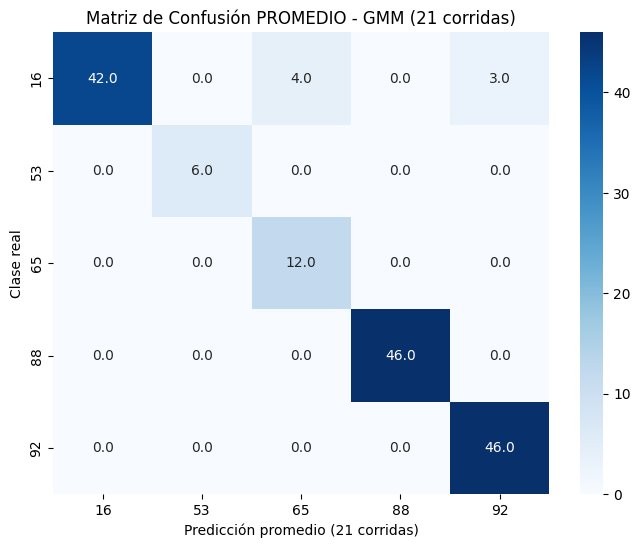

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================
#     GMM — 21 corridas, métricas promedio y CM promedio
# =============================================================

N_RUNS = 21

acc_list = []
f1_list = []
balacc_list = []
cms = []

seeds = np.arange(1, N_RUNS + 1)

for seed in seeds:
    # 1) Entrenar un GMM por clase con este seed
    gmm_models_tmp = {}
    for t in class_targets:
        mask = (y_train == t)
        Xk = X_train_arr[mask.values]

        gmm = GaussianMixture(
            n_components=1,
            covariance_type='full',
            reg_covar=1e-6,
            random_state=seed      # <-- cambia en cada corrida
        )
        gmm.fit(Xk)
        gmm_models_tmp[t] = gmm

    log_prior_tmp = -np.log(n_classes)

    # 2) Función de predicción para este conjunto de GMM
    def gmm_predict_tmp(X):
        log_probs = np.zeros((X.shape[0], n_classes))
        for idx, t in enumerate(class_targets):
            gmm = gmm_models_tmp[t]
            log_probs[:, idx] = gmm.score_samples(X) + log_prior_tmp
        best_idx = np.argmax(log_probs, axis=1)
        preds = np.array([class_targets[i] for i in best_idx])
        return preds

    # 3) Predicciones en validación
    y_pred_valid_tmp = gmm_predict_tmp(X_valid_arr)

    # 4) Métricas
    acc  = accuracy_score(y_valid, y_pred_valid_tmp)
    f1m  = f1_score(y_valid, y_pred_valid_tmp, average='macro')
    balc = balanced_accuracy_score(y_valid, y_pred_valid_tmp)

    acc_list.append(acc)
    f1_list.append(f1m)
    balacc_list.append(balc)

    # 5) Matriz de confusión de esta corrida (solo se guarda)
    cm_tmp = confusion_matrix(
        y_valid,
        y_pred_valid_tmp,
        labels=class_targets
    )
    cms.append(cm_tmp)

# =============================================================
#     RESULTADOS PROMEDIO + DESVIACIONES
# =============================================================

print("\n=== GMM (21 corridas) ===")
print(f"Accuracy promedio       : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"F1-macro promedio       : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"Balanced Accuracy prom. : {np.mean(balacc_list):.4f} ± {np.std(balacc_list):.4f}")

# =============================================================
#     MATRIZ DE CONFUSIÓN PROMEDIO (ÚNICA QUE SE MUESTRA)
# =============================================================
cm_mean = np.mean(cms, axis=0)   # promedio elemento a elemento

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mean, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción promedio (21 corridas)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión PROMEDIO - GMM (21 corridas)")
plt.show()


### MLP

Pesos de clase (MLP): {0: np.float64(0.6523076923076923), 1: np.float64(5.3), 2: np.float64(2.706382978723404), 3: np.float64(0.691304347826087), 4: np.float64(0.6838709677419355)}
Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - accuracy: 0.2830 - loss: 1.9756 - val_accuracy: 0.1195 - val_loss: 1.6338
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3932 - loss: 1.6128 - val_accuracy: 0.1509 - val_loss: 1.6553
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4462 - loss: 1.2837 - val_accuracy: 0.1509 - val_loss: 1.6704
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5183 - loss: 1.2136 - val_accuracy: 0.1509 - val_loss: 1.6822
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5787 - loss: 0.9261 - val_accuracy: 0.2390 - val_loss: 1.6744
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6223 - loss: 0.8462 - val_accuracy: 0.2956 - val_loss: 1.6835
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - ac

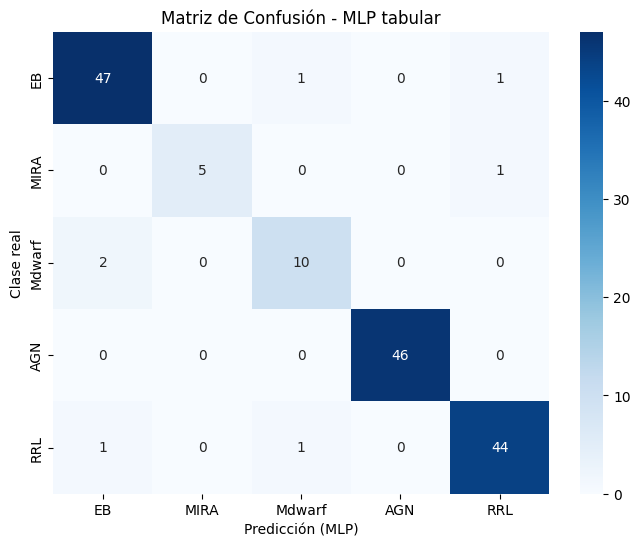

In [ ]:
# === MLP para datos tabulares (en vez de CNN 1D) ===
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import f1_score, balanced_accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Aseguramos arrays
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_arr = X_train_scaled.values
else:
    X_train_arr = X_train_scaled

if isinstance(X_valid_scaled, pd.DataFrame):
    X_valid_arr = X_valid_scaled.values
else:
    X_valid_arr = X_valid_scaled

n_features = X_train_arr.shape[1]

# Codificar y (targets numéricos)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
num_classes = len(le.classes_)

# Pesos de clase
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Pesos de clase (MLP):", class_weight_dict)

# --- Modelo MLP sencillo ---
model = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_arr, y_train_enc,
    epochs=300,
    batch_size=32,
    validation_data=(X_valid_arr, y_valid_enc),
    callbacks=[es],
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluación
train_loss, train_acc = model.evaluate(X_train_arr, y_train_enc, verbose=0)
valid_loss, valid_acc = model.evaluate(X_valid_arr, y_valid_enc, verbose=0)
print("\n=== MLP: Accuracy ===")
print(f"Train      : {train_acc:.4f}")
print(f"Validación : {valid_acc:.4f}")

# Predicciones y matriz de confusión
y_pred_prob = model.predict(X_valid_arr)
y_pred_enc = np.argmax(y_pred_prob, axis=1)

from sklearn.metrics import confusion_matrix

# ==== MÉTRICAS ADICIONALES ====
f1_macro = f1_score(y_valid_enc, y_pred_enc, average='macro')
bal_acc  = balanced_accuracy_score(y_valid_enc, y_pred_enc)

print("\n=== MLP: Métricas adicionales ===")
print(f"F1-macro          : {f1_macro:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")
# ================================


# mismo orden de targets que en RF/GMM/CNN
class_targets = sorted(dataset['target'].unique())
label_map = (dataset[['target', 'type']]
             .drop_duplicates()
             .set_index('target')['type']
             .to_dict())
class_names = [label_map[t] for t in class_targets]

# transformar a espacio del encoder
labels_enc = le.transform(class_targets)

cm_mlp = confusion_matrix(
    y_valid_enc,
    y_pred_enc,
    labels=labels_enc
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción (MLP)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - MLP tabular")
plt.show()


### Trabajo con bandas únicas

Shape per_band_used: (4770, 11)
Bandas disponibles: ['g', 'i', 'r', 'u', 'y', 'z']
Categories (6, object): ['g', 'i', 'r', 'u', 'y', 'z']

Entrenando modelo para banda g
Accuracy banda g          : 0.8703
F1-macro banda g          : 0.7958
Balanced accuracy banda g : 0.7769


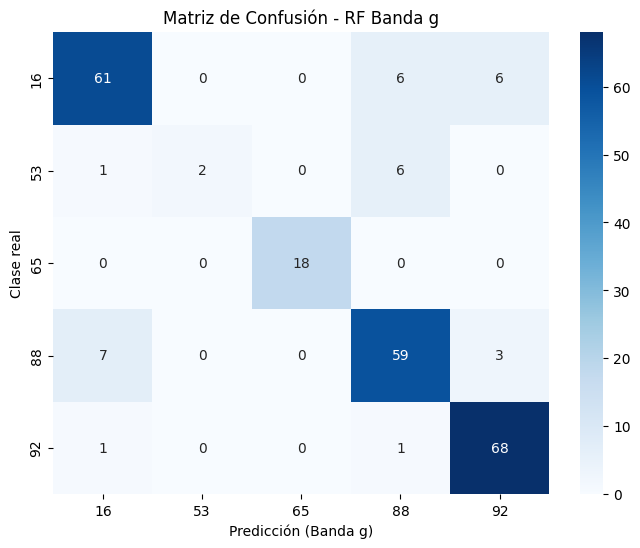


Entrenando modelo para banda i
Accuracy banda i          : 0.8619
F1-macro banda i          : 0.8217
Balanced accuracy banda i : 0.8096


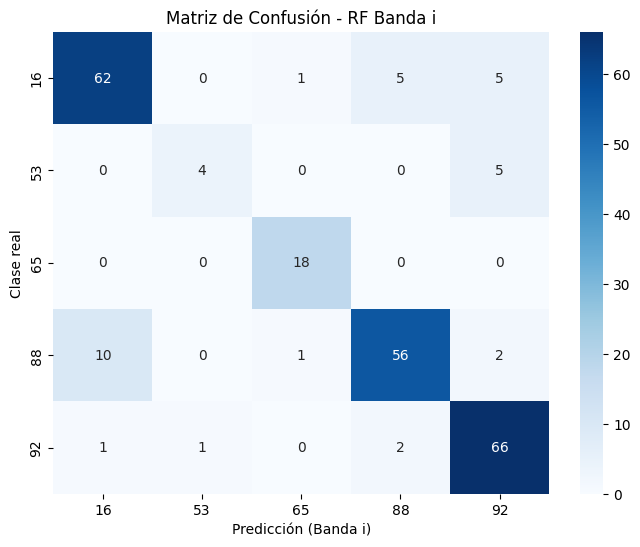


Entrenando modelo para banda r
Accuracy banda r          : 0.8577
F1-macro banda r          : 0.8049
Balanced accuracy banda r : 0.7879


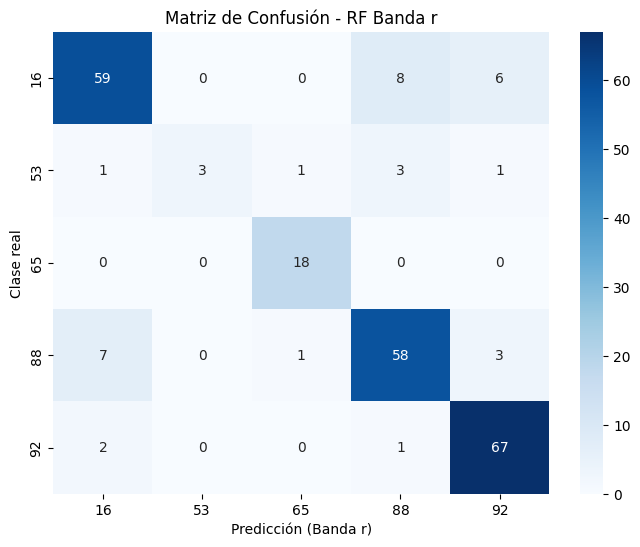


Entrenando modelo para banda u
Accuracy banda u          : 0.7155
F1-macro banda u          : 0.6008
Balanced accuracy banda u : 0.6321


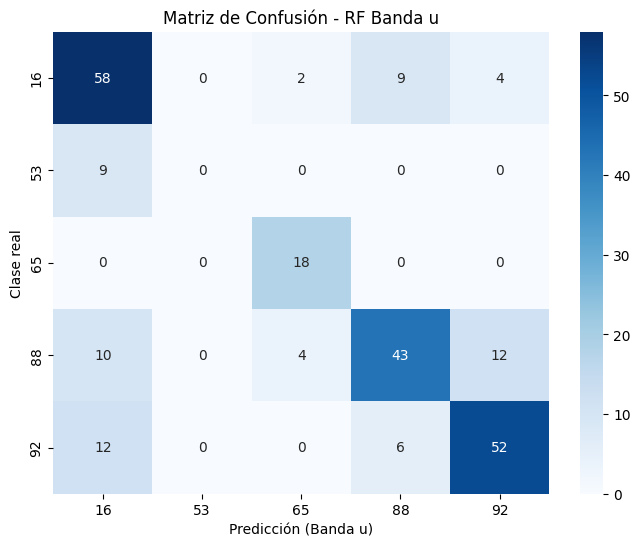


Entrenando modelo para banda y
Accuracy banda y          : 0.7992
F1-macro banda y          : 0.7967
Balanced accuracy banda y : 0.7590


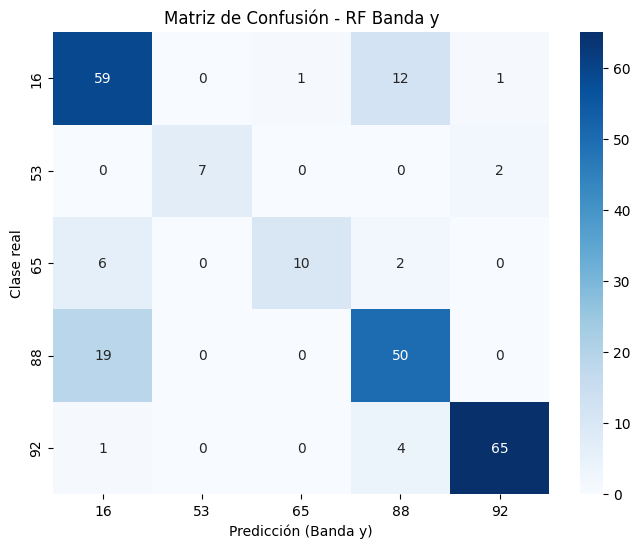


Entrenando modelo para banda z
Accuracy banda z          : 0.8536
F1-macro banda z          : 0.8638
Balanced accuracy banda z : 0.8628


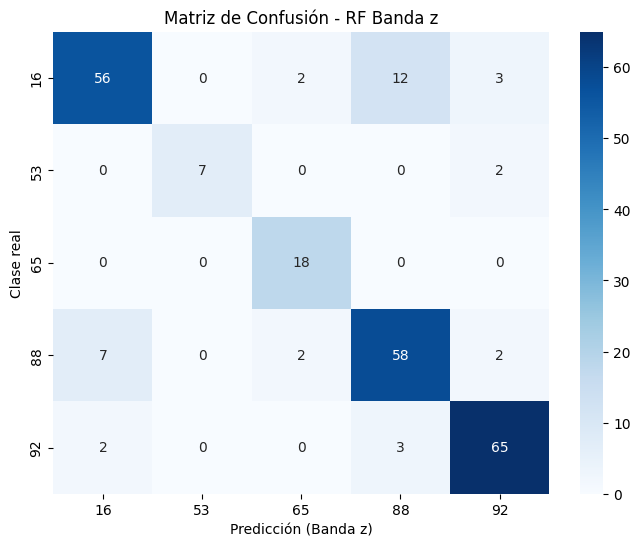

,band,accuracy,f1_macro,balanced_acc
5,z,0.853556,0.863798,0.862810
1,i,0.861925,0.821698,0.809642
2,r,0.857741,0.804890,0.787855
4,y,0.799163,0.796689,0.758952
0,g,0.870293,0.795767,0.776868
3,u,0.715481,0.600796,0.632113


In [ ]:
# RANDOM FOREST

# ============================================================
# Clasificadores por banda (Single-band Random Forest)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Nos quedamos solo con los objetos que están en el dataset final
obj_targets = dataset[["object_id", "target"]].drop_duplicates()

# Junta info por banda con el target
per_band_used = per_band.merge(obj_targets, on="object_id", how="inner")

print("Shape per_band_used:", per_band_used.shape)
print("Bandas disponibles:", per_band_used["band"].unique())

# 2) Entrenamos un Random Forest independiente para cada banda
resultados_bandas = []
bandas = sorted(per_band_used["band"].unique())   # típicamente ['g','i','r','u','Y','z']

cm_por_banda = {}   # <--- AQUI guardaremos todas las matrices

for b in bandas:
    print("\n==============================")
    print(f"Entrenando modelo para banda {b}")
    print("==============================")

    df_b = per_band_used[per_band_used["band"] == b].copy()

    feature_cols_b = [
        c for c in df_b.columns
        if c not in ["object_id", "target", "band"]
    ]

    X = df_b[feature_cols_b].values
    y = df_b["target"].values

    X_train_b, X_valid_b, y_train_b, y_valid_b = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    scaler_b = MinMaxScaler()
    X_train_b_sc = scaler_b.fit_transform(X_train_b)
    X_valid_b_sc = scaler_b.transform(X_valid_b)

    rf_b = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
    rf_b.fit(X_train_b_sc, y_train_b)

    y_pred_valid_b = rf_b.predict(X_valid_b_sc)

    acc  = accuracy_score(y_valid_b, y_pred_valid_b)
    f1m  = f1_score(y_valid_b, y_pred_valid_b, average="macro")
    balc = balanced_accuracy_score(y_valid_b, y_pred_valid_b)

    print(f"Accuracy banda {b}          : {acc:.4f}")
    print(f"F1-macro banda {b}          : {f1m:.4f}")
    print(f"Balanced accuracy banda {b} : {balc:.4f}")

    # <-- AQUÍ estaba el problema: faltaba guardar los resultados
    resultados_bandas.append({
        "band": b,
        "accuracy": acc,
        "f1_macro": f1m,
        "balanced_acc": balc
    })

    # ------ MATRIZ DE CONFUSIÓN ------
    cm_b = confusion_matrix(
        y_valid_b,
        y_pred_valid_b,
        labels=class_targets
    )
    cm_por_banda[b] = cm_b  # <--- guardar

    # Heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel(f"Predicción (Banda {b})")
    plt.ylabel("Clase real")
    plt.title(f"Matriz de Confusión - RF Banda {b}")
    plt.show()

# 3) Resumen en una tabla ordenada por F1-macro
resultados_bandas_df = pd.DataFrame(resultados_bandas)
display(resultados_bandas_df.sort_values("f1_macro", ascending=False))


Shape per_band_used: (4770, 11)
Bandas disponibles: ['g', 'i', 'r', 'u', 'y', 'z']
Categories (6, object): ['g', 'i', 'r', 'u', 'y', 'z']

CNN 1D para banda g
Pesos de clase banda g : {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Accuracy train  banda g: 0.5647
Accuracy valid banda g: 0.5439
F1-macro banda g          : 0.4431
Balanced accuracy banda g : 0.5059


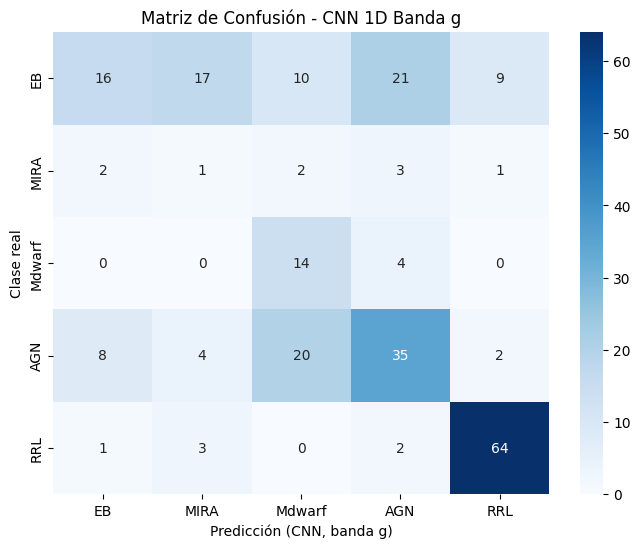


CNN 1D para banda i
Pesos de clase banda i : {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Accuracy train  banda i: 0.5881
Accuracy valid banda i: 0.5649
F1-macro banda i          : 0.4204
Balanced accuracy banda i : 0.4329


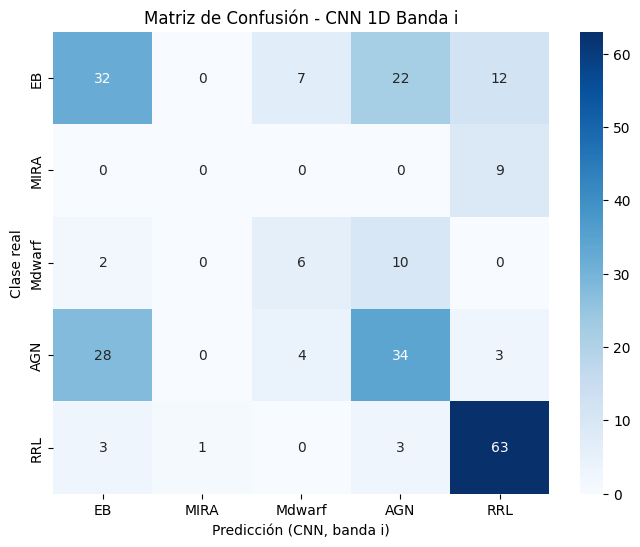


CNN 1D para banda r
Pesos de clase banda r : {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Accuracy train  banda r: 0.6547
Accuracy valid banda r: 0.6402
F1-macro banda r          : 0.5310
Balanced accuracy banda r : 0.5361


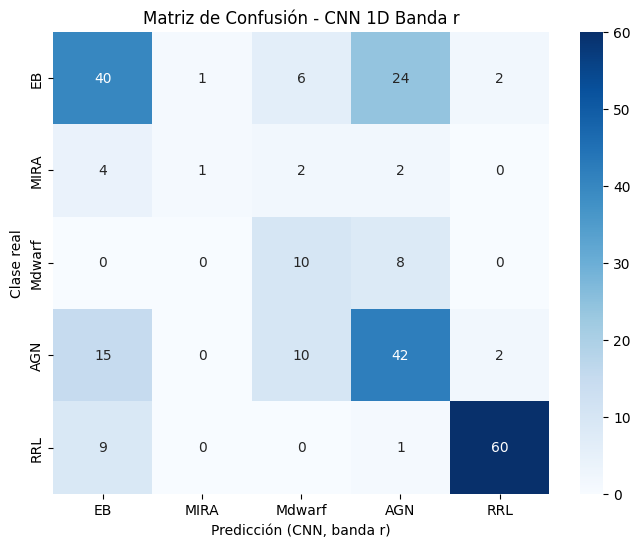


CNN 1D para banda u
Pesos de clase banda u : {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Accuracy train  banda u: 0.2914
Accuracy valid banda u: 0.2929
F1-macro banda u          : 0.0936
Balanced accuracy banda u : 0.2000


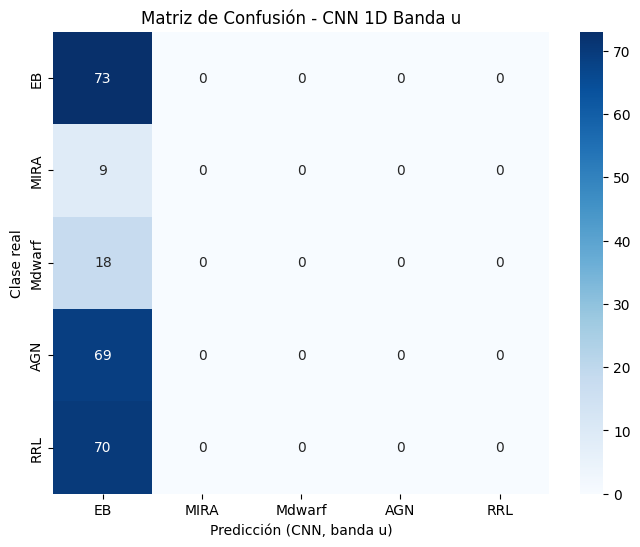


CNN 1D para banda y
Pesos de clase banda y : {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Accuracy train  banda y: 0.2914
Accuracy valid banda y: 0.2929
F1-macro banda y          : 0.0936
Balanced accuracy banda y : 0.2000


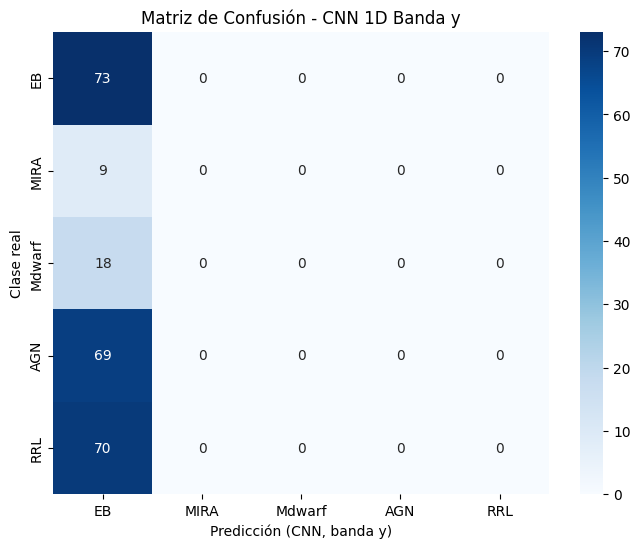


CNN 1D para banda z
Pesos de clase banda z : {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Accuracy train  banda z: 0.2914
Accuracy valid banda z: 0.2929
F1-macro banda z          : 0.0936
Balanced accuracy banda z : 0.2000


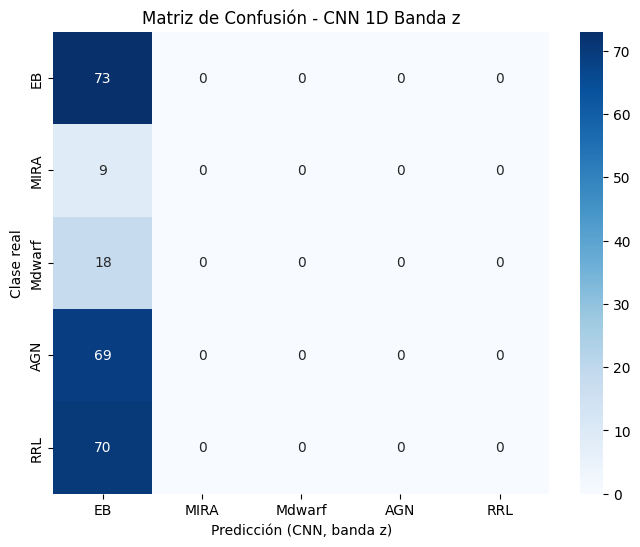

,band,acc_train,acc_valid,f1_macro,balanced_acc
2,r,0.654676,0.640167,0.530968,0.536090
0,g,0.564748,0.543933,0.443085,0.505920
1,i,0.588130,0.564854,0.420385,0.432889
3,u,0.291367,0.292887,0.093590,0.200000
4,y,0.291367,0.292887,0.093590,0.200000
5,z,0.291367,0.292887,0.093590,0.200000


In [ ]:
# CNN 1D POR BANDA (SINGLE-BAND)

# ============================================================
# CNN 1D por banda (Single-band)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
import matplotlib.pyplot as plt

# Si no tienes per_band_used definido (por si acaso):
obj_targets = dataset[["object_id", "target"]].drop_duplicates()
per_band_used = per_band.merge(obj_targets, on="object_id", how="inner")

print("Shape per_band_used:", per_band_used.shape)
print("Bandas disponibles:", per_band_used["band"].unique())

resultados_cnn_bandas = []
bandas = sorted(per_band_used["band"].unique())

cm_cnn_por_banda = {}   # <--- aquí guardaremos las matrices de confusión

for b in bandas:
    print("\n===================================")
    print(f"CNN 1D para banda {b}")
    print("===================================")

    df_b = per_band_used[per_band_used["band"] == b].copy()

    # Features: todas menos id, target y banda
    feature_cols_b = [
        c for c in df_b.columns
        if c not in ["object_id", "target", "band"]
    ]

    X = df_b[feature_cols_b].values
    y = df_b["target"].values

    # Split train/valid
    X_train_b, X_valid_b, y_train_b, y_valid_b = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    # Escalado
    scaler_b = MinMaxScaler()
    X_train_b_sc = scaler_b.fit_transform(X_train_b)
    X_valid_b_sc = scaler_b.transform(X_valid_b)

    n_features_b = X_train_b_sc.shape[1]

    # ---- Preparar para CNN: (n_samples, n_features, 1) ----
    X_train_cnn = X_train_b_sc.reshape(-1, n_features_b, 1)
    X_valid_cnn = X_valid_b_sc.reshape(-1, n_features_b, 1)

    # Codificar y
    le_b = LabelEncoder()
    y_train_b_enc = le_b.fit_transform(y_train_b)
    y_valid_b_enc = le_b.transform(y_valid_b)
    num_classes_b = len(le_b.classes_)

    # Pesos de clase para esta banda
    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_b_enc),
        y=y_train_b_enc
    )
    class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
    print("Pesos de clase banda", b, ":", class_weight_dict)

    # --------- Definir modelo CNN 1D ---------
    model = models.Sequential([
        layers.Input(shape=(n_features_b, 1)),
        layers.Conv1D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes_b, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_cnn, y_train_b_enc,
        epochs=200,
        batch_size=32,
        validation_data=(X_valid_cnn, y_valid_b_enc),
        callbacks=[es],
        class_weight=class_weight_dict,
        verbose=0  # pon 1 si quieres ver las epochs
    )

    # Evaluación
    train_loss, train_acc = model.evaluate(X_train_cnn, y_train_b_enc, verbose=0)
    valid_loss, valid_acc = model.evaluate(X_valid_cnn, y_valid_b_enc, verbose=0)

    print(f"Accuracy train  banda {b}: {train_acc:.4f}")
    print(f"Accuracy valid banda {b}: {valid_acc:.4f}")

    # Predicciones y métricas extra
    y_pred_prob_b = model.predict(X_valid_cnn, verbose=0)
    y_pred_b_enc  = np.argmax(y_pred_prob_b, axis=1)

    f1m  = f1_score(y_valid_b_enc, y_pred_b_enc, average="macro")
    balc = balanced_accuracy_score(y_valid_b_enc, y_pred_b_enc)

    print(f"F1-macro banda {b}          : {f1m:.4f}")
    print(f"Balanced accuracy banda {b} : {balc:.4f}")

    resultados_cnn_bandas.append({
        "band": b,
        "acc_train": train_acc,
        "acc_valid": valid_acc,
        "f1_macro": f1m,
        "balanced_acc": balc
    })

    # ========= MATRIZ DE CONFUSIÓN POR BANDA =========
    # Queremos seguir usando el mismo label_map / class_targets cuando sea posible
    # Tomamos solo las clases globales que están presentes en esta banda
    present_targets = [t for t in class_targets if t in le_b.classes_]
    labels_enc_b = le_b.transform(present_targets)
    class_names_b = [label_map[t] for t in present_targets]

    cm_b = confusion_matrix(
        y_valid_b_enc,
        y_pred_b_enc,
        labels=labels_enc_b
    )
    cm_cnn_por_banda[b] = cm_b   # guardamos la CM de esta banda

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names_b,
                yticklabels=class_names_b)
    plt.xlabel(f"Predicción (CNN, banda {b})")
    plt.ylabel("Clase real")
    plt.title(f"Matriz de Confusión - CNN 1D Banda {b}")
    plt.show()

# Resumen
resultados_cnn_bandas_df = pd.DataFrame(resultados_cnn_bandas)
display(resultados_cnn_bandas_df.sort_values("f1_macro", ascending=False))


Shape per_band_used: (4770, 11)
Bandas disponibles: ['g', 'i', 'r', 'u', 'y', 'z']
Categories (6, object): ['g', 'i', 'r', 'u', 'y', 'z']

GMM por banda g
Filas eliminadas por NaN en banda g: 0
Targets usados en banda g : [np.int64(16), np.int64(53), np.int64(65), np.int64(88), np.int64(92)]
  Entrenando GMM para clase 16, n=171
  Entrenando GMM para clase 53, n=21
  Entrenando GMM para clase 65, n=41
  Entrenando GMM para clase 88, n=161
  Entrenando GMM para clase 92, n=162
Accuracy train  banda g: 0.5863
Accuracy valid banda g: 0.5816
F1-macro banda g          : 0.5028
Balanced accuracy banda g : 0.6046


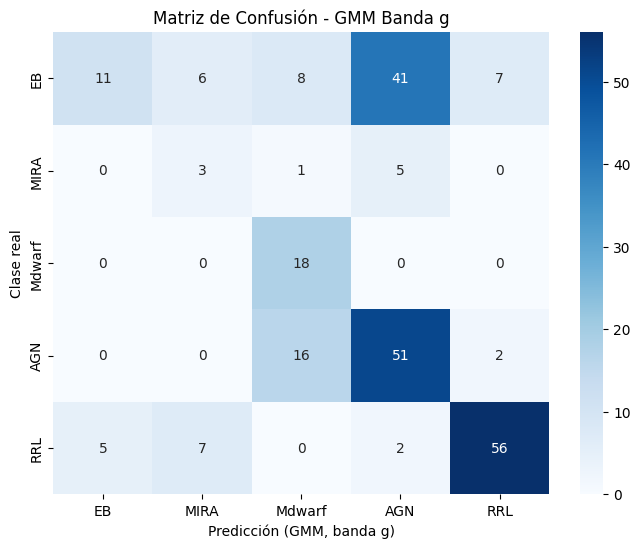


GMM por banda i
Filas eliminadas por NaN en banda i: 0
Targets usados en banda i : [np.int64(16), np.int64(53), np.int64(65), np.int64(88), np.int64(92)]
  Entrenando GMM para clase 16, n=171
  Entrenando GMM para clase 53, n=21
  Entrenando GMM para clase 65, n=41
  Entrenando GMM para clase 88, n=161
  Entrenando GMM para clase 92, n=162
Accuracy train  banda i: 0.5036
Accuracy valid banda i: 0.5732
F1-macro banda i          : 0.5599
Balanced accuracy banda i : 0.6739


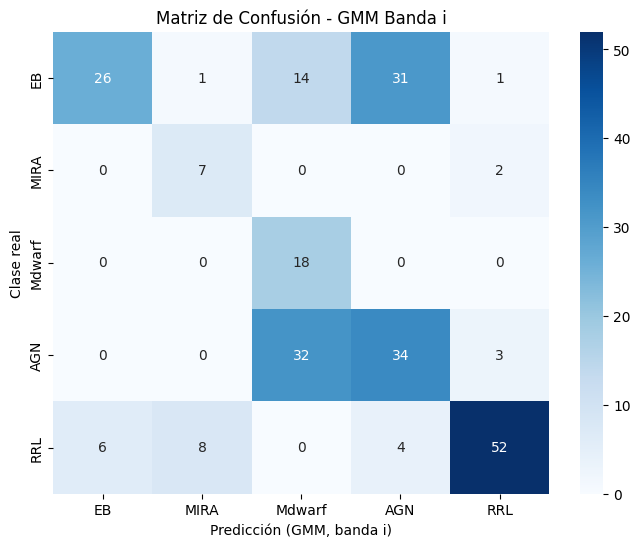


GMM por banda r
Filas eliminadas por NaN en banda r: 0
Targets usados en banda r : [np.int64(16), np.int64(53), np.int64(65), np.int64(88), np.int64(92)]
  Entrenando GMM para clase 16, n=171
  Entrenando GMM para clase 53, n=21
  Entrenando GMM para clase 65, n=41
  Entrenando GMM para clase 88, n=161
  Entrenando GMM para clase 92, n=162
Accuracy train  banda r: 0.6277
Accuracy valid banda r: 0.6402
F1-macro banda r          : 0.6059
Balanced accuracy banda r : 0.7208


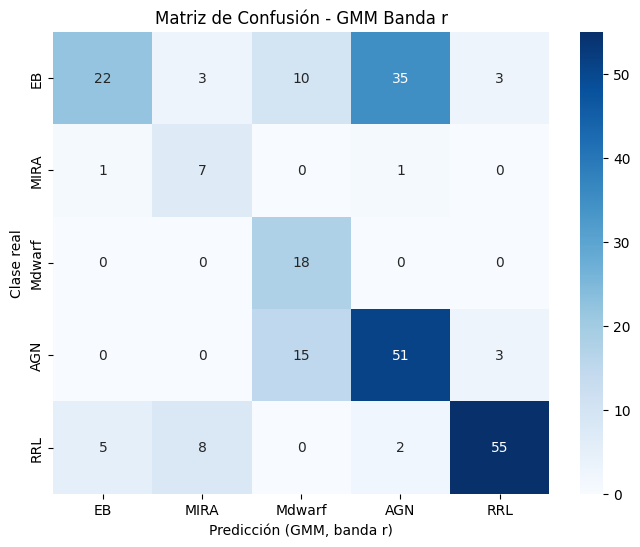


GMM por banda u
Filas eliminadas por NaN en banda u: 253
Targets usados en banda u : [np.int64(16), np.int64(65), np.int64(88), np.int64(92)]
  Entrenando GMM para clase 16, n=58
  Entrenando GMM para clase 65, n=39
  Entrenando GMM para clase 88, n=147
  Entrenando GMM para clase 92, n=135
Accuracy train  banda u: 0.6174
Accuracy valid banda u: 0.5706
F1-macro banda u          : 0.5598
Balanced accuracy banda u : 0.6262


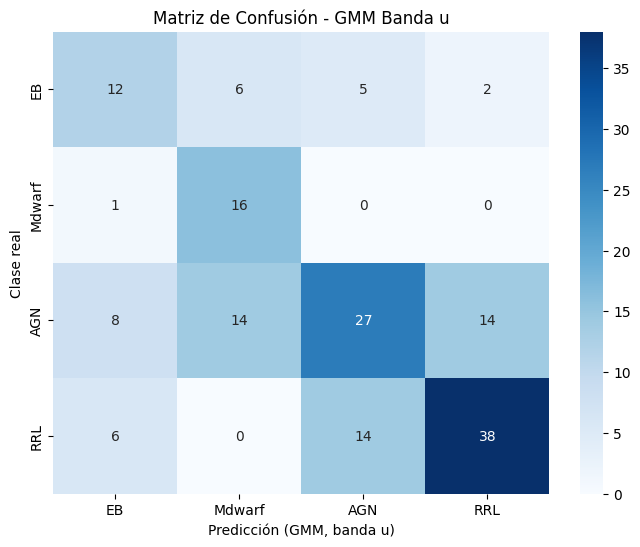


GMM por banda y
Filas eliminadas por NaN en banda y: 103
Targets usados en banda y : [np.int64(16), np.int64(53), np.int64(65), np.int64(88), np.int64(92)]
  Entrenando GMM para clase 16, n=128
  Entrenando GMM para clase 53, n=21
  Entrenando GMM para clase 65, n=26
  Entrenando GMM para clase 88, n=147
  Entrenando GMM para clase 92, n=162
Accuracy train  banda y: 0.6116
Accuracy valid banda y: 0.5337
F1-macro banda y          : 0.5587
Balanced accuracy banda y : 0.6191


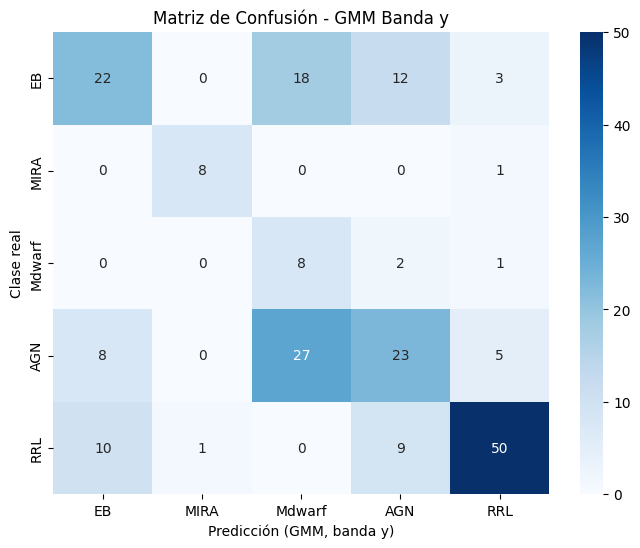


GMM por banda z
Filas eliminadas por NaN en banda z: 15
Targets usados en banda z : [np.int64(16), np.int64(53), np.int64(65), np.int64(88), np.int64(92)]
  Entrenando GMM para clase 16, n=169
  Entrenando GMM para clase 53, n=21
  Entrenando GMM para clase 65, n=32
  Entrenando GMM para clase 88, n=161
  Entrenando GMM para clase 92, n=163
Accuracy train  banda z: 0.4872
Accuracy valid banda z: 0.4786
F1-macro banda z          : 0.5122
Balanced accuracy banda z : 0.6356


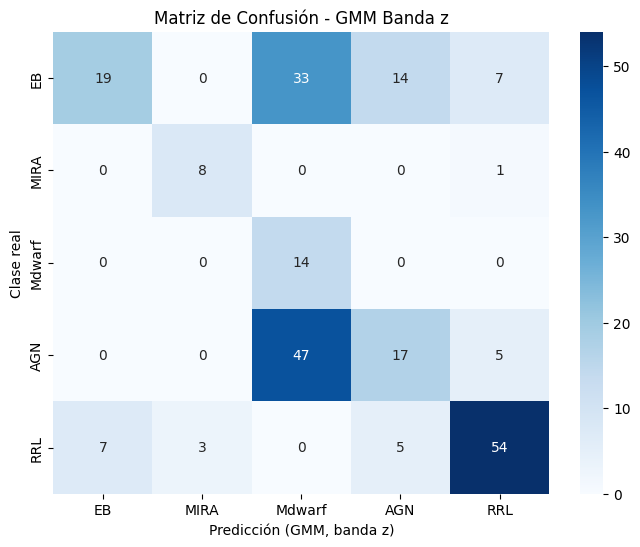

,band,acc_train,acc_valid,f1_macro,balanced_acc
2,r,0.627698,0.640167,0.605918,0.720798
1,i,0.503597,0.573222,0.559903,0.673911
3,u,0.617414,0.570552,0.559824,0.626230
4,y,0.611570,0.533654,0.558659,0.619105
5,z,0.487179,0.478632,0.512205,0.635630
0,g,0.586331,0.581590,0.502825,0.604630


In [ ]:
# ============================================================
# GMM por banda (Single-band Gaussian Mixture Model) - SIN NaN
# ============================================================

import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

obj_targets = dataset[["object_id", "target"]].drop_duplicates()
per_band_used = per_band.merge(obj_targets, on="object_id", how="inner")

print("Shape per_band_used:", per_band_used.shape)
print("Bandas disponibles:", per_band_used["band"].unique())

resultados_gmm_bandas = []
bandas = sorted(per_band_used["band"].unique())

cm_gmm_por_banda = {}   # <--- aquí guardaremos las matrices de confusión

for b in bandas:
    print("\n===================================")
    print(f"GMM por banda {b}")
    print("===================================")

    df_b = per_band_used[per_band_used["band"] == b].copy()

    # Features: todas menos id, target y banda
    feature_cols_b = [
        c for c in df_b.columns
        if c not in ["object_id", "target", "band"]
    ]

    # ---- ELIMINAR FILAS CON NaN EN ALGUNA FEATURE ----
    before = len(df_b)
    df_b = df_b.dropna(subset=feature_cols_b).reset_index(drop=True)
    after = len(df_b)
    print(f"Filas eliminadas por NaN en banda {b}: {before - after}")

    X = df_b[feature_cols_b].values
    y = df_b["target"].values  # códigos numéricos

    # Por seguridad: si quedan muy pocos datos, saltamos la banda
    if len(df_b) < len(np.unique(y)) * 5:
        print(f"Demasiado pocos datos limpios en banda {b}, se omite.")
        continue

    # Split train/valid
    X_train_b, X_valid_b, y_train_b, y_valid_b = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    # Escalado
    scaler_b = MinMaxScaler()
    X_train_b_sc = scaler_b.fit_transform(X_train_b)
    X_valid_b_sc = scaler_b.transform(X_valid_b)

    # Clases presentes en el train de esta banda
    class_targets_b = sorted(np.unique(y_train_b))
    n_classes_b = len(class_targets_b)

    print("Targets usados en banda", b, ":", class_targets_b)

    # -------------------------------------------------------
    # Entrenar un GMM (1 componente) por clase en esta banda
    # -------------------------------------------------------
    gmm_models_b = {}
    for t in class_targets_b:
        mask_t = (y_train_b == t)
        Xk = X_train_b_sc[mask_t]

        print(f"  Entrenando GMM para clase {t}, n={Xk.shape[0]}")

        gmm = GaussianMixture(
            n_components=1,
            covariance_type="full",
            reg_covar=1e-6,
            random_state=42
        )
        gmm.fit(Xk)
        gmm_models_b[t] = gmm

    # Priors iguales
    log_prior_b = -np.log(n_classes_b)

    # -------------------------------------------------------
    # Función de predicción GMM para esta banda
    # -------------------------------------------------------
    def gmm_predict_band(X_sc):
        log_probs = np.zeros((X_sc.shape[0], n_classes_b))
        for idx, t in enumerate(class_targets_b):
            gmm = gmm_models_b[t]
            log_probs[:, idx] = gmm.score_samples(X_sc) + log_prior_b
        best_idx = np.argmax(log_probs, axis=1)
        preds = np.array([class_targets_b[i] for i in best_idx])
        return preds

    # Predicciones
    y_pred_train_b = gmm_predict_band(X_train_b_sc)
    y_pred_valid_b = gmm_predict_band(X_valid_b_sc)

    # Métricas
    acc_train = accuracy_score(y_train_b, y_pred_train_b)
    acc_valid = accuracy_score(y_valid_b, y_pred_valid_b)
    f1m       = f1_score(y_valid_b, y_pred_valid_b, average="macro")
    balc      = balanced_accuracy_score(y_valid_b, y_pred_valid_b)

    print(f"Accuracy train  banda {b}: {acc_train:.4f}")
    print(f"Accuracy valid banda {b}: {acc_valid:.4f}")
    print(f"F1-macro banda {b}          : {f1m:.4f}")
    print(f"Balanced accuracy banda {b} : {balc:.4f}")

    resultados_gmm_bandas.append({
        "band": b,
        "acc_train": acc_train,
        "acc_valid": acc_valid,
        "f1_macro": f1m,
        "balanced_acc": balc
    })

    # ========= MATRIZ DE CONFUSIÓN POR BANDA =========
    # Nombres de clase para esta banda (usando label_map global)
    class_names_b = [label_map[t] for t in class_targets_b]

    cm_b = confusion_matrix(
        y_valid_b,
        y_pred_valid_b,
        labels=class_targets_b
    )
    cm_gmm_por_banda[b] = cm_b   # guardamos CM de esta banda

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names_b,
                yticklabels=class_names_b)
    plt.xlabel(f"Predicción (GMM, banda {b})")
    plt.ylabel("Clase real")
    plt.title(f"Matriz de Confusión - GMM Banda {b}")
    plt.show()

# Resumen de desempeño por banda
resultados_gmm_bandas_df = pd.DataFrame(resultados_gmm_bandas)
display(resultados_gmm_bandas_df.sort_values("f1_macro", ascending=False))


### Fusionamiento de Bandas.

Usando columna de banda: band
Bandas disponibles: ['g', 'i', 'r', 'u', 'y', 'z']
Objetos con todas las bandas: 795
Objetos train: 556
Objetos valid: 239
Clases (encoder): [16 53 65 88 92]

Random Forest por banda g
Accuracy banda g          : 0.8703
F1-macro banda g          : 0.7958
Balanced accuracy banda g : 0.7769

Random Forest por banda i
Accuracy banda i          : 0.8619
F1-macro banda i          : 0.8217
Balanced accuracy banda i : 0.8096

Random Forest por banda r
Accuracy banda r          : 0.8577
F1-macro banda r          : 0.8049
Balanced accuracy banda r : 0.7879

Random Forest por banda u
Accuracy banda u          : 0.7155
F1-macro banda u          : 0.6008
Balanced accuracy banda u : 0.6321

Random Forest por banda y
Accuracy banda y          : 0.7992
F1-macro banda y          : 0.7967
Balanced accuracy banda y : 0.7590

Random Forest por banda z
Accuracy banda z          : 0.8536
F1-macro banda z          : 0.8638
Balanced accuracy banda z : 0.8628

== Ensemble multi-b

,band,accuracy,f1_macro,balanced_acc
5,z,0.853556,0.863798,0.862810
1,i,0.861925,0.821698,0.809642
2,r,0.857741,0.804890,0.787855
4,y,0.799163,0.796689,0.758952
0,g,0.870293,0.795767,0.776868
3,u,0.715481,0.600796,0.632113


Resultados del ensemble (fila extra):


,band,accuracy,f1_macro,balanced_acc
0,g,0.870293,0.795767,0.776868
1,i,0.861925,0.821698,0.809642
2,r,0.857741,0.804890,0.787855
3,u,0.715481,0.600796,0.632113
4,y,0.799163,0.796689,0.758952
5,z,0.853556,0.863798,0.862810
6,ENSEMBLE,0.924686,0.927061,0.910532


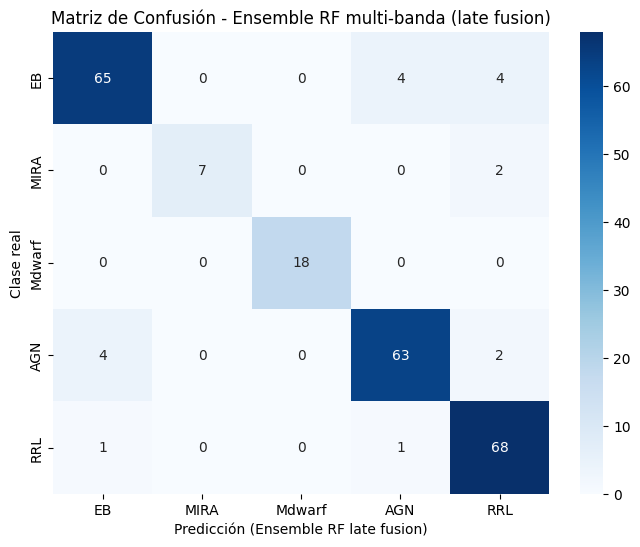

In [ ]:
# ============================================================
# Ensemble multi-banda con Random Forest (late fusion)
# ============================================================


# ---------- 0) Detectar nombre de columna de banda ----------
if "band" in per_band.columns:
    band_col = "band"
elif "band_ds" in per_band.columns:
    band_col = "band_ds"
else:
    raise ValueError("No se encontró columna de banda ('band' o 'band_ds') en per_band")

print("Usando columna de banda:", band_col)

# ---------- 1) Objetos y targets (a nivel de objeto) ----------
obj_targets = dataset[["object_id", "target"]].drop_duplicates()

# Queremos objetos que tengan TODAS las bandas disponibles
num_bands_total = per_band[band_col].nunique()
bands_sorted = sorted(per_band[band_col].unique())
print("Bandas disponibles:", bands_sorted)

band_counts = per_band.groupby("object_id")[band_col].nunique()
objects_allbands = band_counts[band_counts == num_bands_total].index

obj_targets_all = obj_targets[obj_targets["object_id"].isin(objects_allbands)].reset_index(drop=True)
print("Objetos con todas las bandas:", len(obj_targets_all))

# ---------- 2) Split train/valid a nivel de objeto ----------
X_ids = obj_targets_all["object_id"].values
y_targets = obj_targets_all["target"].values

obj_train, obj_valid, y_train_obj, y_valid_obj = train_test_split(
    X_ids,
    y_targets,
    test_size=0.3,
    random_state=42,
    stratify=y_targets
)

print("Objetos train:", len(obj_train))
print("Objetos valid:", len(obj_valid))

# Codificar targets (para tener 0..K-1 consistente en todas las bandas)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_obj)
y_valid_enc = le.transform(y_valid_obj)
class_names = le.classes_
n_classes = len(class_names)
print("Clases (encoder):", class_names)

# Para facilitar el orden
train_ids_list = list(obj_train)
valid_ids_list = list(obj_valid)
ordered_ids = train_ids_list + valid_ids_list  # primero train, luego valid

# ---------- 3) Preparar per_band solo con objetos elegibles ----------
per_band_used = per_band[per_band["object_id"].isin(objects_allbands)].copy()

# ---------- 4) Entrenar un RF por banda y obtener predict_proba ----------
probas_valid_por_banda = []
resultados_rf_band = []

for b in bands_sorted:
    print("\n===================================")
    print(f"Random Forest por banda {b}")
    print("===================================")

    df_b = per_band_used[per_band_used[band_col] == b].copy()

    # Asegurar una fila por objeto y ordenar según ordered_ids
    df_b_idx = (df_b
                .set_index("object_id")
                .loc[ordered_ids]         # mismo orden: train + valid
                .reset_index())

    # Features: todas menos id, target y banda
    feature_cols_b = [
        c for c in df_b_idx.columns
        if c not in ["object_id", "target", band_col]
    ]

    X_all = df_b_idx[feature_cols_b].values

    # Split de features siguiendo el mismo orden (train luego valid)
    n_train = len(train_ids_list)
    X_train_b = X_all[:n_train]
    X_valid_b = X_all[n_train:]

    # Escalado
    scaler_b = MinMaxScaler()
    X_train_b_sc = scaler_b.fit_transform(X_train_b)
    X_valid_b_sc = scaler_b.transform(X_valid_b)

    # RF para esta banda, usando y_train_enc (ya alineado con obj_train)
    rf_b = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
    rf_b.fit(X_train_b_sc, y_train_enc)

    # Métricas individuales por banda (opcional, pero útil)
    y_pred_valid_b = rf_b.predict(X_valid_b_sc)
    acc_b  = accuracy_score(y_valid_enc, y_pred_valid_b)
    f1m_b  = f1_score(y_valid_enc, y_pred_valid_b, average="macro")
    balc_b = balanced_accuracy_score(y_valid_enc, y_pred_valid_b)

    print(f"Accuracy banda {b}          : {acc_b:.4f}")
    print(f"F1-macro banda {b}          : {f1m_b:.4f}")
    print(f"Balanced accuracy banda {b} : {balc_b:.4f}")

    resultados_rf_band.append({
        "band": b,
        "accuracy": acc_b,
        "f1_macro": f1m_b,
        "balanced_acc": balc_b
    })

    # Probabilidades en validación (para el ensemble)
    # rf_b.classes_ está en orden 0..K-1 (porque entrenamos con y_train_enc)
    proba_valid_b = rf_b.predict_proba(X_valid_b_sc)   # shape: (n_valid, n_classes)
    probas_valid_por_banda.append(proba_valid_b)

# ---------- 5) Ensemble late fusion: promedio de probabilidades ----------
probas_valid_por_banda = np.array(probas_valid_por_banda)    # (n_bandas, n_valid, n_classes)
proba_ens = probas_valid_por_banda.mean(axis=0)              # (n_valid, n_classes)

y_pred_ens = np.argmax(proba_ens, axis=1)                    # en espacio encodificado (0..K-1)

acc_ens  = accuracy_score(y_valid_enc, y_pred_ens)
f1m_ens  = f1_score(y_valid_enc, y_pred_ens, average="macro")
balc_ens = balanced_accuracy_score(y_valid_enc, y_pred_ens)

print("\n===================================")
print("== Ensemble multi-banda (late fusion RF) ==")
print("===================================")
print(f"Accuracy (ensemble)          : {acc_ens:.4f}")
print(f"F1-macro (ensemble)          : {f1m_ens:.4f}")
print(f"Balanced accuracy (ensemble) : {balc_ens:.4f}")

# Tabla resumen por banda + ensemble
resultados_rf_band_df = pd.DataFrame(resultados_rf_band)
print("\nDesempeño por banda (RF single-band):")
display(resultados_rf_band_df.sort_values("f1_macro", ascending=False))

print("Resultados del ensemble (fila extra):")
res_ens = pd.DataFrame([{
    "band": "ENSEMBLE",
    "accuracy": acc_ens,
    "f1_macro": f1m_ens,
    "balanced_acc": balc_ens
}])
display(pd.concat([resultados_rf_band_df, res_ens], ignore_index=True))


# ============================================================
# Matriz de confusión para el ensemble RF (late fusion)
# ============================================================

from sklearn.metrics import confusion_matrix

# Si no tienes label_map definido en esta celda, lo volvemos a crear:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Clases en espacio original (targets numéricos) y sus nombres
class_targets = list(le.classes_)              # los mismos que usó el LabelEncoder
class_names   = [label_map[t] for t in class_targets]

# En el espacio del encoder, las clases son 0..K-1
labels_enc = np.arange(n_classes)

cm_ens = confusion_matrix(
    y_valid_enc,
    y_pred_ens,
    labels=labels_enc
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ens, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción (Ensemble RF late fusion)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - Ensemble RF multi-banda (late fusion)")
plt.show()


Usando columna de banda: band
Bandas disponibles: ['g', 'i', 'r', 'u', 'y', 'z']
Objetos con todas las bandas disponibles: 795
Clases codificadas: [16 53 65 88 92]

CNN 1D por banda g
Accuracy valid banda g   : 0.6820
F1-macro banda g         : 0.5150
Balanced accuracy banda g: 0.5112

CNN 1D por banda i
Accuracy valid banda i   : 0.6611
F1-macro banda i         : 0.4950
Balanced accuracy banda i: 0.5082

CNN 1D por banda r
Accuracy valid banda r   : 0.6946
F1-macro banda r         : 0.5431
Balanced accuracy banda r: 0.5465

CNN 1D por banda u
Accuracy valid banda u   : 0.2929
F1-macro banda u         : 0.0936
Balanced accuracy banda u: 0.2000

CNN 1D por banda y
Accuracy valid banda y   : 0.2929
F1-macro banda y         : 0.0936
Balanced accuracy banda y: 0.2000

CNN 1D por banda z
Accuracy valid banda z   : 0.2929
F1-macro banda z         : 0.0936
Balanced accuracy banda z: 0.2000

== Ensemble multi-banda CNN 1D ==
Accuracy ensemble          : 0.3054
F1-macro ensemble          : 0.09

,band,acc_valid,f1_macro,balanced_acc
2,r,0.694561,0.543058,0.546511
0,g,0.682008,0.514985,0.511224
1,i,0.661088,0.494983,0.508203
3,u,0.292887,0.093590,0.200000
4,y,0.292887,0.093590,0.200000
5,z,0.292887,0.093590,0.200000


Resumen final:


,band,acc_valid,f1_macro,balanced_acc
0,g,0.682008,0.514985,0.511224
1,i,0.661088,0.494983,0.508203
2,r,0.694561,0.543058,0.546511
3,u,0.292887,0.093590,0.200000
4,y,0.292887,0.093590,0.200000
5,z,0.292887,0.093590,0.200000
6,ENSEMBLE,0.305439,0.093590,0.200000


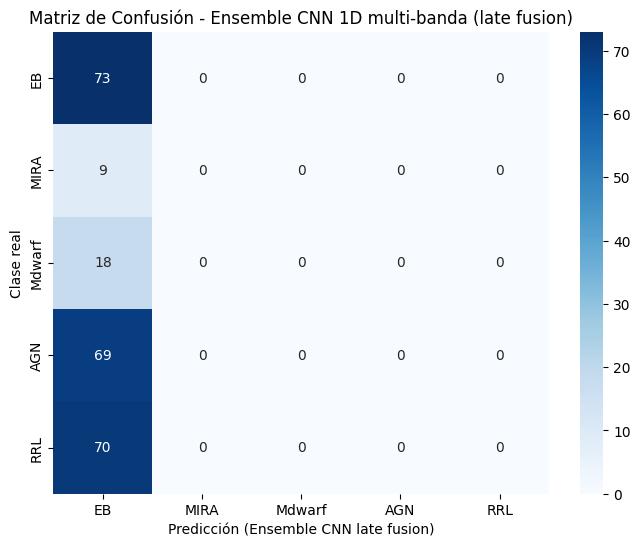

In [ ]:
# ============================================================
# Ensemble multi-banda con CNN 1D (late fusion)
# ============================================================

# ---------- 0) Detectar columna de banda ----------
if "band" in per_band.columns:
    band_col = "band"
elif "band_ds" in per_band.columns:
    band_col = "band_ds"
else:
    raise ValueError("No se encontró columna de banda ('band' o 'band_ds').")

print("Usando columna de banda:", band_col)

# ---------- 1) Objetos y targets ----------
obj_targets = dataset[["object_id", "target"]].drop_duplicates()

num_bands_total = per_band[band_col].nunique()
bands_sorted = sorted(per_band[band_col].unique())
print("Bandas disponibles:", bands_sorted)

# Objetos que tienen todas las bandas
band_counts = per_band.groupby("object_id")[band_col].nunique()
objects_allbands = band_counts[band_counts == num_bands_total].index

obj_targets_all = obj_targets[obj_targets["object_id"].isin(objects_allbands)].reset_index(drop=True)
print("Objetos con todas las bandas disponibles:", len(obj_targets_all))

# ---------- 2) Split a nivel de objeto ----------
X_ids = obj_targets_all["object_id"].values
y_targets = obj_targets_all["target"].values

obj_train, obj_valid, y_train_obj, y_valid_obj = train_test_split(
    X_ids,
    y_targets,
    test_size=0.3,
    random_state=42,
    stratify=y_targets
)

train_ids = list(obj_train)
valid_ids = list(obj_valid)
ordered_ids = train_ids + valid_ids

# Codificar y
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_obj)
y_valid_enc = le.transform(y_valid_obj)
class_names = le.classes_
n_classes = len(class_names)
print("Clases codificadas:", class_names)

# ---------- 3) Preparar per_band para estos objetos ----------
per_band_used = per_band[per_band["object_id"].isin(objects_allbands)].copy()

# ---------- 4) CNN por banda + predict_proba ----------
probas_valid_por_banda = []
resultados_cnn_band = []

for b in bands_sorted:
    print("\n===================================")
    print(f"CNN 1D por banda {b}")
    print("===================================")

    df_b = per_band_used[per_band_used[band_col] == b].copy()

    # Ordenar una fila por objeto según ordered_ids
    df_b_idx = (df_b
                .set_index("object_id")
                .loc[ordered_ids]
                .reset_index())

    # Features
    feature_cols_b = [
        c for c in df_b_idx.columns
        if c not in ["object_id", "target", band_col]
    ]

    X_all = df_b_idx[feature_cols_b].values
    n_train = len(train_ids)

    X_train_b = X_all[:n_train]
    X_valid_b = X_all[n_train:]

    # Escalado
    scaler_b = MinMaxScaler()
    X_train_b_sc = scaler_b.fit_transform(X_train_b)
    X_valid_b_sc = scaler_b.transform(X_valid_b)

    n_features_b = X_train_b_sc.shape[1]

    # Reshape para CNN: (samples, features, 1)
    X_train_cnn = X_train_b_sc.reshape(-1, n_features_b, 1)
    X_valid_cnn = X_valid_b_sc.reshape(-1, n_features_b, 1)

    # ---- Definir modelo CNN ----
    model = models.Sequential([
        layers.Input(shape=(n_features_b, 1)),
        layers.Conv1D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    # Entrenar sólo sobre objetos de esta banda
    history = model.fit(
        X_train_cnn, y_train_enc,
        epochs=200,
        batch_size=32,
        validation_data=(X_valid_cnn, y_valid_enc),
        callbacks=[es],
        verbose=0
    )

    # Evaluación normal
    train_loss, train_acc = model.evaluate(X_train_cnn, y_train_enc, verbose=0)
    valid_loss, valid_acc = model.evaluate(X_valid_cnn, y_valid_enc, verbose=0)

    # Predicción por banda
    y_pred_prob_b = model.predict(X_valid_cnn, verbose=0)
    y_pred_b = np.argmax(y_pred_prob_b, axis=1)

    f1m_b  = f1_score(y_valid_enc, y_pred_b, average="macro")
    balc_b = balanced_accuracy_score(y_valid_enc, y_pred_b)

    print(f"Accuracy valid banda {b}   : {valid_acc:.4f}")
    print(f"F1-macro banda {b}         : {f1m_b:.4f}")
    print(f"Balanced accuracy banda {b}: {balc_b:.4f}")

    resultados_cnn_band.append({
        "band": b,
        "acc_valid": valid_acc,
        "f1_macro": f1m_b,
        "balanced_acc": balc_b
    })

    # Guardar probabilidades
    probas_valid_por_banda.append(y_pred_prob_b)

# Convertir lista → array (bands, samples, classes)
probas_valid_por_banda = np.array(probas_valid_por_banda)

# ---------- 5) Ensemble: promedio de probabilidades ----------
proba_ens = probas_valid_por_banda.mean(axis=0)
y_pred_ens = np.argmax(proba_ens, axis=1)

acc_ens  = accuracy_score(y_valid_enc, y_pred_ens)
f1m_ens  = f1_score(y_valid_enc, y_pred_ens, average="macro")
balc_ens = balanced_accuracy_score(y_valid_enc, y_pred_ens)

print("\n===================================")
print("== Ensemble multi-banda CNN 1D ==")
print("===================================")
print(f"Accuracy ensemble          : {acc_ens:.4f}")
print(f"F1-macro ensemble          : {f1m_ens:.4f}")
print(f"Balanced accuracy ensemble : {balc_ens:.4f}")

# ---------- 6) Tabla resumen ----------
resultados_cnn_band_df = pd.DataFrame(resultados_cnn_band)
display(resultados_cnn_band_df.sort_values("f1_macro", ascending=False))

res_ens = pd.DataFrame([{
    "band": "ENSEMBLE",
    "acc_valid": acc_ens,
    "f1_macro": f1m_ens,
    "balanced_acc": balc_ens
}])

print("Resumen final:")
display(pd.concat([resultados_cnn_band_df, res_ens], ignore_index=True))

# ============================================================
# Matriz de confusión para el ensemble CNN 1D (late fusion)
# ============================================================

from sklearn.metrics import confusion_matrix

# Si no tienes label_map definido en esta celda, lo creamos:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Clases en espacio original (targets numéricos) y nombres legibles
class_targets = list(le.classes_)              # mismos targets usados por el LabelEncoder
class_names   = [label_map[t] for t in class_targets]

# En el espacio codificado, las clases son 0..K-1
labels_enc = np.arange(n_classes)

cm_ens_cnn = confusion_matrix(
    y_valid_enc,
    y_pred_ens,
    labels=labels_enc
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ens_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción (Ensemble CNN late fusion)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - Ensemble CNN 1D multi-banda (late fusion)")
plt.show()




Usando columna de banda: band
Bandas disponibles: ['g', 'i', 'r', 'u', 'y', 'z']
Objetos con todas las bandas: 795
Clases (encoder): [16 53 65 88 92]

GMM multi-banda: banda g
  Entrenando GMM banda g, clase 0 (16), n=171
  Entrenando GMM banda g, clase 1 (53), n=21
  Entrenando GMM banda g, clase 2 (65), n=41
  Entrenando GMM banda g, clase 3 (88), n=161
  Entrenando GMM banda g, clase 4 (92), n=162
Accuracy valid banda g   : 0.5816
F1-macro banda g         : 0.5028
Balanced accuracy banda g: 0.6046

GMM multi-banda: banda i
  Entrenando GMM banda i, clase 0 (16), n=171
  Entrenando GMM banda i, clase 1 (53), n=21
  Entrenando GMM banda i, clase 2 (65), n=41
  Entrenando GMM banda i, clase 3 (88), n=161
  Entrenando GMM banda i, clase 4 (92), n=162
Accuracy valid banda i   : 0.5732
F1-macro banda i         : 0.5599
Balanced accuracy banda i: 0.6739

GMM multi-banda: banda r
  Entrenando GMM banda r, clase 0 (16), n=171
  Entrenando GMM banda r, clase 1 (53), n=21
  Entrenando GMM band

,band,acc_valid,f1_macro,balanced_acc
2,r,0.640167,0.605918,0.720798
1,i,0.573222,0.559903,0.673911
4,y,0.493724,0.521218,0.610577
5,z,0.464435,0.506445,0.618825
0,g,0.581590,0.502825,0.604630
3,u,0.447699,0.436836,0.627051


Resumen final:


,band,acc_valid,f1_macro,balanced_acc
0,g,0.581590,0.502825,0.604630
1,i,0.573222,0.559903,0.673911
2,r,0.640167,0.605918,0.720798
3,u,0.447699,0.436836,0.627051
4,y,0.493724,0.521218,0.610577
5,z,0.464435,0.506445,0.618825
6,ENSEMBLE,0.631799,0.649433,0.733683


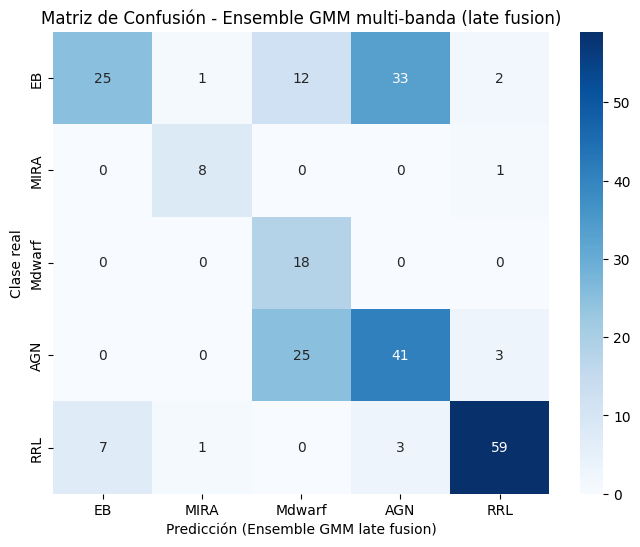

In [ ]:
# ============================================================
# Ensemble multi-banda con GMM (late fusion)
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.mixture import GaussianMixture
from scipy.special import logsumexp

# ---------- 0) Detectar columna de banda ----------
if "band" in per_band.columns:
    band_col = "band"
elif "band_ds" in per_band.columns:
    band_col = "band_ds"
else:
    raise ValueError("No se encontró columna de banda ('band' o 'band_ds').")

print("Usando columna de banda:", band_col)

# ---------- 1) Objetos y targets ----------
obj_targets = dataset[["object_id", "target"]].drop_duplicates()

num_bands_total = per_band[band_col].nunique()
bands_sorted = sorted(per_band[band_col].unique())
print("Bandas disponibles:", bands_sorted)

# Objetos que tienen TODAS las bandas
band_counts = per_band.groupby("object_id")[band_col].nunique()
objects_allbands = band_counts[band_counts == num_bands_total].index

obj_targets_all = obj_targets[obj_targets["object_id"].isin(objects_allbands)].reset_index(drop=True)
print("Objetos con todas las bandas:", len(obj_targets_all))

# ---------- 2) Split a nivel de objeto ----------
X_ids = obj_targets_all["object_id"].values
y_targets = obj_targets_all["target"].values

obj_train, obj_valid, y_train_obj, y_valid_obj = train_test_split(
    X_ids,
    y_targets,
    test_size=0.3,
    random_state=42,
    stratify=y_targets
)

train_ids = list(obj_train)
valid_ids = list(obj_valid)
ordered_ids = train_ids + valid_ids

# Codificar labels a 0..K-1 (más cómodo para GMM)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_obj)
y_valid_enc = le.transform(y_valid_obj)
n_classes = len(le.classes_)
print("Clases (encoder):", le.classes_)

# Mapa object_id -> y_enc (para alinear fácil)
y_train_enc_dict = dict(zip(train_ids, y_train_enc))
y_valid_enc_dict = dict(zip(valid_ids, y_valid_enc))

# ---------- 3) per_band limitado a estos objetos ----------
per_band_used = per_band[per_band["object_id"].isin(objects_allbands)].copy()

# ---------- 4) GMM por banda + probabilidades ----------
probas_valid_por_banda = []
resultados_gmm_band = []

for b in bands_sorted:
    print("\n===================================")
    print(f"GMM multi-banda: banda {b}")
    print("===================================")

    df_b = per_band_used[per_band_used[band_col] == b].copy()

    # Una fila por objeto, en el orden [train_ids, valid_ids]
    df_b_idx = (df_b
                .set_index("object_id")
                .loc[ordered_ids]
                .reset_index())

    # Features: todas menos id, target (si existiera) y banda
    feature_cols_b = [
        c for c in df_b_idx.columns
        if c not in ["object_id", "target", band_col]
    ]

    X_all_raw = df_b_idx[feature_cols_b].values

    # Imputar NaN por mediana de cada feature (GMM no acepta NaN)
    imputer_b = SimpleImputer(strategy="median")
    X_all = imputer_b.fit_transform(X_all_raw)

    # Split en train/valid siguiendo el orden
    n_train = len(train_ids)
    X_train_b = X_all[:n_train]
    X_valid_b = X_all[n_train:]

    # Construir vectores y_enc en el mismo orden
    y_train_b_enc = np.array([y_train_enc_dict[oid] for oid in train_ids])
    y_valid_b_enc = np.array([y_valid_enc_dict[oid] for oid in valid_ids])

    # Escalado
    scaler_b = MinMaxScaler()
    X_train_b_sc = scaler_b.fit_transform(X_train_b)
    X_valid_b_sc = scaler_b.transform(X_valid_b)

    # ---- Entrenar un GMM por clase (1 componente) ----
    gmm_models_b = {}
    classes_enc = np.arange(n_classes)

    for c in classes_enc:
        mask_c = (y_train_b_enc == c)
        Xc = X_train_b_sc[mask_c]

        print(f"  Entrenando GMM banda {b}, clase {c} ({le.classes_[c]}), n={Xc.shape[0]}")

        gmm = GaussianMixture(
            n_components=1,
            covariance_type="full",
            reg_covar=1e-6,
            random_state=42
        )
        gmm.fit(Xc)
        gmm_models_b[c] = gmm

    log_prior = -np.log(n_classes)

    # ---- Función para obtener probabilidades posterior p(clase|x) ----
    def gmm_proba_band(X_sc):
        # X_sc: (n_samples, n_features)
        log_probs = np.zeros((X_sc.shape[0], n_classes))
        for idx, c in enumerate(classes_enc):
            gmm = gmm_models_b[c]
            log_probs[:, idx] = gmm.score_samples(X_sc) + log_prior

        # Normalizar log-probs → probs
        # log p_k - logsumexp(log p_j)
        log_probs_norm = log_probs - logsumexp(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs_norm)
        return probs  # shape (n_samples, n_classes)

    # Probabilidades y predicciones en validación
    proba_valid_b = gmm_proba_band(X_valid_b_sc)
    y_pred_valid_b = np.argmax(proba_valid_b, axis=1)

    acc_b  = accuracy_score(y_valid_b_enc, y_pred_valid_b)
    f1m_b  = f1_score(y_valid_b_enc, y_pred_valid_b, average="macro")
    balc_b = balanced_accuracy_score(y_valid_b_enc, y_pred_valid_b)

    print(f"Accuracy valid banda {b}   : {acc_b:.4f}")
    print(f"F1-macro banda {b}         : {f1m_b:.4f}")
    print(f"Balanced accuracy banda {b}: {balc_b:.4f}")

    resultados_gmm_band.append({
        "band": b,
        "acc_valid": acc_b,
        "f1_macro": f1m_b,
        "balanced_acc": balc_b
    })

    # Guardamos probabilidades para el ensemble
    probas_valid_por_banda.append(proba_valid_b)

# ---------- 5) Ensemble late fusion: promedio de probabilidades ----------
probas_valid_por_banda = np.array(probas_valid_por_banda)   # (n_bandas, n_valid, n_classes)
proba_ens = probas_valid_por_banda.mean(axis=0)             # (n_valid, n_classes)
y_pred_ens = np.argmax(proba_ens, axis=1)

acc_ens  = accuracy_score(y_valid_enc, y_pred_ens)
f1m_ens  = f1_score(y_valid_enc, y_pred_ens, average="macro")
balc_ens = balanced_accuracy_score(y_valid_enc, y_pred_ens)

print("\n===================================")
print("== Ensemble multi-banda GMM ==")
print("===================================")
print(f"Accuracy ensemble          : {acc_ens:.4f}")
print(f"F1-macro ensemble          : {f1m_ens:.4f}")
print(f"Balanced accuracy ensemble : {balc_ens:.4f}")

# ---------- 6) Tabla resumen ----------
resultados_gmm_band_df = pd.DataFrame(resultados_gmm_band)
display(resultados_gmm_band_df.sort_values("f1_macro", ascending=False))

res_ens = pd.DataFrame([{
    "band": "ENSEMBLE",
    "acc_valid": acc_ens,
    "f1_macro": f1m_ens,
    "balanced_acc": balc_ens
}])

print("Resumen final:")
display(pd.concat([resultados_gmm_band_df, res_ens], ignore_index=True))


# ============================================================
# Matriz de confusión para el ensemble GMM (late fusion)
# ============================================================

from sklearn.metrics import confusion_matrix

# Si no tienes label_map definido en esta celda, lo creamos:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Clases en espacio original (targets numéricos) y nombres legibles
class_targets = list(le.classes_)              # mismos targets que usó el LabelEncoder
class_names   = [label_map[t] for t in class_targets]

# En el espacio codificado, las clases son 0..K-1
labels_enc = np.arange(n_classes)

cm_ens_gmm = confusion_matrix(
    y_valid_enc,
    y_pred_ens,
    labels=labels_enc
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ens_gmm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción (Ensemble GMM late fusion)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión - Ensemble GMM multi-banda (late fusion)")
plt.show()



### Early fusion

In [ ]:
# ============================================================
# Early fusion: construir features multi-banda (pivot)
# ============================================================


# Detectar columna de banda en per_band
if "band" in per_band.columns:
    band_col = "band"
elif "band_ds" in per_band.columns:
    band_col = "band_ds"
else:
    raise ValueError("No se encontró columna de banda ('band' o 'band_ds') en per_band")

print("Usando columna de banda:", band_col)

# Objetos y targets (ya filtrados, sin uLens-Single_GenLens)
obj_targets = dataset[["object_id", "target"]].drop_duplicates()

# Nos quedamos solo con objetos que están en dataset
per_band_used = per_band[per_band["object_id"].isin(obj_targets["object_id"])].copy()

print("Shape per_band_used:", per_band_used.shape)
print("Bandas disponibles:", sorted(per_band_used[band_col].unique()))

# ---------------- Pivot: una fila por objeto, columnas por banda ----------------
wide = per_band_used.pivot(
    index="object_id",
    columns=band_col  # cada banda queda como segundo nivel de columna
)

# Flatten de columnas MultiIndex -> nombres tipo "flux_med_b_g"
wide.columns = [
    f"{feat}_b{str(band)}"
    for (feat, band) in wide.columns
]

wide = wide.reset_index()
print("Shape wide (multi-banda early fusion):", wide.shape)
display(wide.head())

# ---------------- Merge con target ----------------
early_df = wide.merge(obj_targets, on="object_id", how="inner")
print("Shape early_df (con target):", early_df.shape)

# Definir columnas de features
feature_cols_early = [
    c for c in early_df.columns
    if c not in ["object_id", "target"]
]

X_raw = early_df[feature_cols_early].values
y = early_df["target"].values

# Imputar NaN con la mediana (por banda/feature)
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_raw)

# Train/valid split a nivel de objeto
X_train_ef, X_valid_ef, y_train_ef, y_valid_ef = train_test_split(
    X_imp,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Escalado Min-Max
scaler = MinMaxScaler()
X_train_ef_sc = scaler.fit_transform(X_train_ef)
X_valid_ef_sc = scaler.transform(X_valid_ef)


Usando columna de banda: band
Shape per_band_used: (4770, 10)
Bandas disponibles: ['g', 'i', 'r', 'u', 'y', 'z']
Shape wide (multi-banda early fusion): (795, 49)


,object_id,n_det_bg,n_det_bi,n_det_br,n_det_bu,n_det_by,n_det_bz,snr_med_bg,snr_med_bi,snr_med_br,...,flux_p95_br,flux_p95_bu,flux_p95_by,flux_p95_bz,amp_rob_bg,amp_rob_bi,amp_rob_br,amp_rob_bu,amp_rob_by,amp_rob_bz
0,615,56,57,57,54,52,57,132.138542,108.846913,137.696272,...,600.718665,120.855450,370.323724,365.200128,1740.649429,896.317213,1277.663159,234.288354,787.191484,780.187372
1,713,11,12,15,9,0,4,9.082306,6.980765,7.502930,...,5.275608,-8.646810,NaN,-9.557947,10.365803,19.910857,15.083589,3.407574,NaN,2.719006
2,2677,10,17,17,0,1,10,8.169997,9.413863,11.156748,...,64.300285,NaN,-63.193478,42.275861,76.164193,95.963533,103.650882,NaN,0.000000,124.938498
3,4088,56,55,56,72,51,53,50.299744,36.496188,47.638099,...,-31.696626,-23.053094,-60.317043,-36.995580,52.879801,52.963880,45.665822,72.473263,71.261211,52.492768
4,4171,27,15,39,0,0,2,6.964771,5.361905,8.890289,...,13.012318,NaN,NaN,-29.013309,5.067061,3.743157,5.625770,NaN,NaN,3.999193


Shape early_df (con target): (795, 50)



=== Random Forest (early fusion, todas las bandas) ===
Accuracy          : 0.9707
F1-macro          : 0.9803
Balanced accuracy : 0.9801


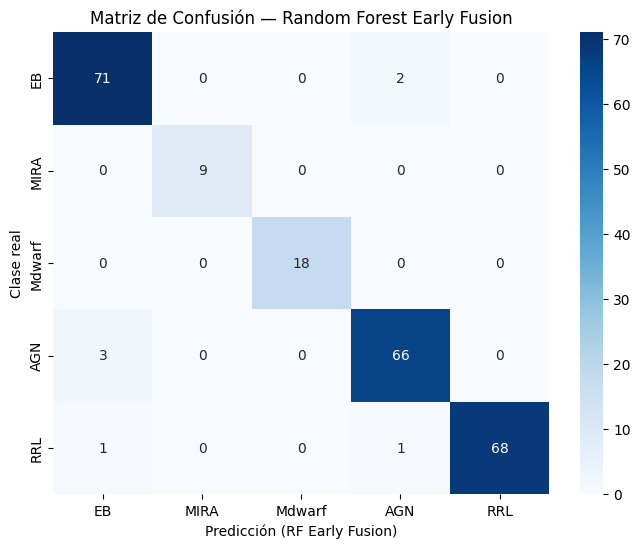

In [ ]:
# ============================================================
# Random Forest con early fusion (todas las bandas concatenadas)
# ============================================================

rf_early = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_early.fit(X_train_ef_sc, y_train_ef)

y_pred_valid_ef = rf_early.predict(X_valid_ef_sc)

acc_ef  = accuracy_score(y_valid_ef, y_pred_valid_ef)
f1m_ef  = f1_score(y_valid_ef, y_pred_valid_ef, average="macro")
balc_ef = balanced_accuracy_score(y_valid_ef, y_pred_valid_ef)

print("\n=== Random Forest (early fusion, todas las bandas) ===")
print(f"Accuracy          : {acc_ef:.4f}")
print(f"F1-macro          : {f1m_ef:.4f}")
print(f"Balanced accuracy : {balc_ef:.4f}")

# ============================================================
# Matriz de Confusión — Random Forest Early Fusion
# ============================================================

from sklearn.metrics import confusion_matrix

# Si no existen en esta celda:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Targets ordenados globalmente
class_targets = sorted(label_map.keys())
class_names   = [label_map[t] for t in class_targets]

# Matriz de confusión en espacio original (targets numéricos)
cm_rf_early = confusion_matrix(
    y_valid_ef,
    y_pred_valid_ef,
    labels=class_targets
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_early, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción (RF Early Fusion)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión — Random Forest Early Fusion")
plt.show()



Clases (encoder early fusion): [16 53 65 88 92]
Shape X_train_cnn_ef: (556, 48, 1)
Shape X_valid_cnn_ef: (239, 48, 1)
Pesos de clase (CNN early fusion): {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.2481 - loss: 1.5978 - val_accuracy: 0.2929 - val_loss: 1.5898
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2944 - loss: 1.6138 - val_accuracy: 0.2929 - val_loss: 1.5900
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2721 - loss: 1.5596 - val_accuracy: 0.3473 - val_loss: 1.5963
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2800 - loss: 1.5187 - val_accuracy: 0.2803 - val_loss: 1.5885
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2835 - loss: 1.5653 - val_accuracy: 0.3849 - val_loss: 1.5648
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━

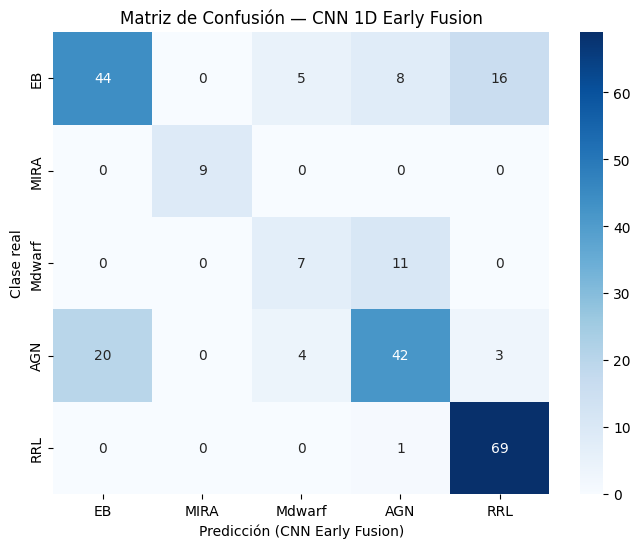

In [ ]:
# ============================================================
# CNN 1D con early fusion (todas las bandas concatenadas)
# ============================================================


# 1) Codificar y en 0..K-1 (por si los targets son 16, 53, etc.)
le_ef = LabelEncoder()
y_train_ef_enc = le_ef.fit_transform(y_train_ef)
y_valid_ef_enc = le_ef.transform(y_valid_ef)
num_classes_ef = len(le_ef.classes_)
print("Clases (encoder early fusion):", le_ef.classes_)

# 2) Preparar X para CNN: (n_samples, n_features, 1)
n_features_ef = X_train_ef_sc.shape[1]
X_train_cnn_ef = X_train_ef_sc.reshape(-1, n_features_ef, 1)
X_valid_cnn_ef = X_valid_ef_sc.reshape(-1, n_features_ef, 1)

print("Shape X_train_cnn_ef:", X_train_cnn_ef.shape)
print("Shape X_valid_cnn_ef:", X_valid_cnn_ef.shape)

# 3) Pesos de clase (para combatir desbalance)
class_weights_array_ef = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_ef_enc),
    y=y_train_ef_enc
)
class_weight_ef = {i: w for i, w in enumerate(class_weights_array_ef)}
print("Pesos de clase (CNN early fusion):", class_weight_ef)

# 4) Definir modelo CNN 1D
model_ef = models.Sequential([
    layers.Input(shape=(n_features_ef, 1)),
    layers.Conv1D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes_ef, activation="softmax")
])

model_ef.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

es_ef = EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True
)

# 5) Entrenamiento
history_ef = model_ef.fit(
    X_train_cnn_ef, y_train_ef_enc,
    epochs=200,
    batch_size=32,
    validation_data=(X_valid_cnn_ef, y_valid_ef_enc),
    callbacks=[es_ef],
    class_weight=class_weight_ef,
    verbose=1
)

# 6) Evaluación
train_loss_ef, train_acc_ef = model_ef.evaluate(X_train_cnn_ef, y_train_ef_enc, verbose=0)
valid_loss_ef, valid_acc_ef = model_ef.evaluate(X_valid_cnn_ef, y_valid_ef_enc, verbose=0)

print("\n=== CNN 1D (early fusion): Accuracy ===")
print(f"Train      : {train_acc_ef:.4f}")
print(f"Validación : {valid_acc_ef:.4f}")

# 7) Métricas adicionales: F1-macro y balanced accuracy
y_pred_prob_ef = model_ef.predict(X_valid_cnn_ef, verbose=0)
y_pred_ef_enc  = np.argmax(y_pred_prob_ef, axis=1)

f1m_ef  = f1_score(y_valid_ef_enc, y_pred_ef_enc, average="macro")
balc_ef = balanced_accuracy_score(y_valid_ef_enc, y_pred_ef_enc)

print("\n=== CNN 1D (early fusion): Métricas ===")
print(f"F1-macro          : {f1m_ef:.4f}")
print(f"Balanced accuracy : {balc_ef:.4f}")


# ============================================================
# Matriz de Confusión — CNN 1D Early Fusion
# ============================================================

from sklearn.metrics import confusion_matrix

# Si no existe label_map en la celda actual, lo recreamos:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Orden de clases en el espacio original
class_targets_ef = list(le_ef.classes_)          # targets reales en orden del LabelEncoder
class_names_ef   = [label_map[t] for t in class_targets_ef]  # nombres legibles

# Las clases en el encoder son 0..K-1:
labels_enc_ef = np.arange(num_classes_ef)

# Matriz de confusión
cm_cnn_ef = confusion_matrix(
    y_valid_ef_enc,
    y_pred_ef_enc,
    labels=labels_enc_ef
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn_ef, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_ef,
            yticklabels=class_names_ef)
plt.xlabel("Predicción (CNN Early Fusion)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión — CNN 1D Early Fusion")
plt.show()


Clases (encoder GMM early fusion): [16 53 65 88 92]
Entrenando GMM early fusion para clase 0 (16), n=171
Entrenando GMM early fusion para clase 1 (53), n=21
Entrenando GMM early fusion para clase 2 (65), n=41
Entrenando GMM early fusion para clase 3 (88), n=161
Entrenando GMM early fusion para clase 4 (92), n=162

=== GMM (early fusion, todas las bandas) ===
Accuracy          : 0.8285
F1-macro          : 0.7354
Balanced accuracy : 0.7494


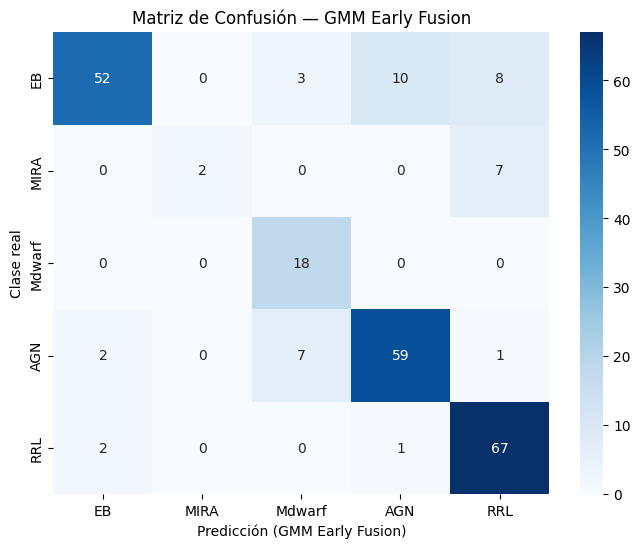

In [ ]:
# ============================================================
# GMM con early fusion (todas las bandas concatenadas)
# ============================================================
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from scipy.special import logsumexp

# Aseguramos que X están como arrays (por si quedaron DataFrames)
if hasattr(X_train_ef_sc, "values"):
    X_train_gmm = X_train_ef_sc.values
else:
    X_train_gmm = X_train_ef_sc

if hasattr(X_valid_ef_sc, "values"):
    X_valid_gmm = X_valid_ef_sc.values
else:
    X_valid_gmm = X_valid_ef_sc

# 1) Codificar y en 0..K-1
le_gmm = LabelEncoder()
y_train_ef_enc = le_gmm.fit_transform(y_train_ef)
y_valid_ef_enc = le_gmm.transform(y_valid_ef)
classes_enc = np.arange(len(le_gmm.classes_))
n_classes = len(classes_enc)

print("Clases (encoder GMM early fusion):", le_gmm.classes_)

# 2) Entrenar un GMM (1 componente) por clase
gmm_models_ef = {}
for c in classes_enc:
    mask_c = (y_train_ef_enc == c)
    Xc = X_train_gmm[mask_c]

    print(f"Entrenando GMM early fusion para clase {c} ({le_gmm.classes_[c]}), n={Xc.shape[0]}")

    gmm = GaussianMixture(
        n_components=1,
        covariance_type="full",
        reg_covar=1e-6,
        random_state=42
    )
    gmm.fit(Xc)
    gmm_models_ef[c] = gmm

log_prior = -np.log(n_classes)

# 3) Función para obtener p(clase | x)
def gmm_proba_early(X):
    # X: (n_samples, n_features)
    log_probs = np.zeros((X.shape[0], n_classes))
    for idx, c in enumerate(classes_enc):
        gmm = gmm_models_ef[c]
        log_probs[:, idx] = gmm.score_samples(X) + log_prior

    # normalizar (log-softmax)
    log_probs_norm = log_probs - logsumexp(log_probs, axis=1, keepdims=True)
    probs = np.exp(log_probs_norm)
    return probs   # (n_samples, n_classes)

# 4) Predicciones y métricas
proba_valid_ef = gmm_proba_early(X_valid_gmm)
y_pred_ef_enc = np.argmax(proba_valid_ef, axis=1)

acc_ef  = accuracy_score(y_valid_ef_enc, y_pred_ef_enc)
f1m_ef  = f1_score(y_valid_ef_enc, y_pred_ef_enc, average="macro")
balc_ef = balanced_accuracy_score(y_valid_ef_enc, y_pred_ef_enc)

print("\n=== GMM (early fusion, todas las bandas) ===")
print(f"Accuracy          : {acc_ef:.4f}")
print(f"F1-macro          : {f1m_ef:.4f}")
print(f"Balanced accuracy : {balc_ef:.4f}")


# ============================================================
# Matriz de Confusión — GMM Early Fusion
# ============================================================
from sklearn.metrics import confusion_matrix

# Si no existe label_map en esta celda, lo creamos:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Orden de clases en el espacio original (targets reales)
class_targets_ef = list(le_gmm.classes_)              # mismos targets que usó el LabelEncoder
class_names_ef   = [label_map[t] for t in class_targets_ef]

# En el espacio codificado, las clases son 0..K-1
labels_enc_ef = np.arange(n_classes)

cm_gmm_ef = confusion_matrix(
    y_valid_ef_enc,
    y_pred_ef_enc,
    labels=labels_enc_ef
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gmm_ef, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_ef,
            yticklabels=class_names_ef)
plt.xlabel("Predicción (GMM Early Fusion)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión — GMM Early Fusion")
plt.show()


### Features cruzadas entre bandas

In [ ]:
# ============================================================
# Features cruzadas entre bandas (colores, ratios, diferencias)
# ============================================================

import numpy as np
import itertools

# Detectar bandas a partir de las columnas flux_med_b*
flux_med_cols = [c for c in early_df.columns if c.startswith("flux_med_b")]
bands = sorted({c.split("_b")[1] for c in flux_med_cols})
print("Bandas detectadas para features cruzadas:", bands)

# 1) COLORES: diferencias de flux_med entre bandas (tipo "color_gr")
for b1, b2 in itertools.combinations(bands, 2):
    c1 = f"flux_med_b{b1}"
    c2 = f"flux_med_b{b2}"
    if c1 in early_df.columns and c2 in early_df.columns:
        new_col = f"color_fluxmed_{b1}{b2}"
        early_df[new_col] = early_df[c1] - early_df[c2]

# 2) RATIOS DE AMPLITUD: amp_rob_b* (si existe)
amp_cols = [c for c in early_df.columns if c.startswith("amp_rob_b")]
if amp_cols:
    for b1, b2 in itertools.combinations(bands, 2):
        a1 = f"amp_rob_b{b1}"
        a2 = f"amp_rob_b{b2}"
        if a1 in early_df.columns and a2 in early_df.columns:
            new_col = f"amp_ratio_{b1}{b2}"
            early_df[new_col] = early_df[a1] / (early_df[a2] + 1e-6)  # evitar /0

# 3) CONTRASTE DE VARIABILIDAD: diferencia de flux_std_b* (si existe)
std_cols = [c for c in early_df.columns if c.startswith("flux_std_b")]
if std_cols:
    for b1, b2 in itertools.combinations(bands, 2):
        s1 = f"flux_std_b{b1}"
        s2 = f"flux_std_b{b2}"
        if s1 in early_df.columns and s2 in early_df.columns:
            new_col = f"std_diff_{b1}{b2}"
            early_df[new_col] = early_df[s1] - early_df[s2]

print("Total de columnas después de añadir features cruzadas:", len(early_df.columns))
display(early_df.head())


Bandas detectadas para features cruzadas: ['g', 'i', 'r', 'u', 'y', 'z']
Total de columnas después de añadir features cruzadas: 95


,object_id,n_det_bg,n_det_bi,n_det_br,n_det_bu,n_det_by,n_det_bz,snr_med_bg,snr_med_bi,snr_med_br,...,std_diff_ir,std_diff_iu,std_diff_iy,std_diff_iz,std_diff_ru,std_diff_ry,std_diff_rz,std_diff_uy,std_diff_uz,std_diff_yz
0,615,56,57,57,54,52,57,132.138542,108.846913,137.696272,...,-120.745590,247.389457,29.913004,43.684349,368.135047,150.658593,164.429939,-217.476453,-203.705108,13.771345
1,713,11,12,15,9,0,4,9.082306,6.980765,7.502930,...,1.631651,5.809004,NaN,5.596818,4.177353,NaN,3.965167,NaN,-0.212186,NaN
2,2677,10,17,17,0,1,10,8.169997,9.413863,11.156748,...,-3.798793,NaN,NaN,-15.953166,NaN,NaN,-12.154373,NaN,NaN,NaN
3,4088,56,55,56,72,51,53,50.299744,36.496188,47.638099,...,2.391717,-3.900914,-6.001342,0.906490,-6.292631,-8.393059,-1.485227,-2.100428,4.807404,6.907832
4,4171,27,15,39,0,0,2,6.964771,5.361905,8.890289,...,-0.593734,NaN,NaN,-1.909389,NaN,NaN,-1.315655,NaN,NaN,NaN


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

# Features = TODO salvo id y target
feature_cols_cross = [
    c for c in early_df.columns
    if c not in ["object_id", "target"]
]

X_raw_cross = early_df[feature_cols_cross].values
y_cross = early_df["target"].values

# Imputación por mediana (por si alguna combinación generó NaN)
imputer_cross = SimpleImputer(strategy="median")
X_imp_cross = imputer_cross.fit_transform(X_raw_cross)

# Train/valid split (mismo esquema)
X_train_cross, X_valid_cross, y_train_cross, y_valid_cross = train_test_split(
    X_imp_cross,
    y_cross,
    test_size=0.3,
    random_state=42,
    stratify=y_cross
)

# Escalado
scaler_cross = MinMaxScaler()
X_train_cross_sc = scaler_cross.fit_transform(X_train_cross)
X_valid_cross_sc = scaler_cross.transform(X_valid_cross)

print("Shapes con features cruzadas:")
print("Train:", X_train_cross_sc.shape, " Valid:", X_valid_cross_sc.shape)


Shapes con features cruzadas:
Train: (556, 93)  Valid: (239, 93)



=== Random Forest (early fusion + features cruzadas) ===
Accuracy          : 0.9791
F1-macro          : 0.9819
Balanced accuracy : 0.9860


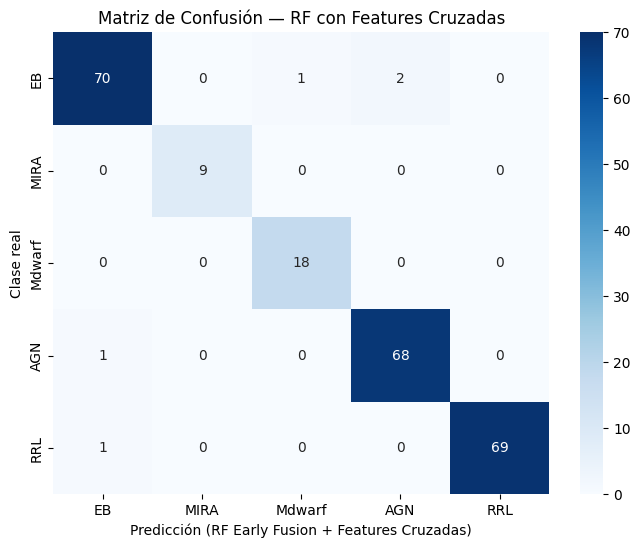

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

rf_cross = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_cross.fit(X_train_cross_sc, y_train_cross)
y_pred_cross = rf_cross.predict(X_valid_cross_sc)

acc_cross  = accuracy_score(y_valid_cross, y_pred_cross)
f1m_cross  = f1_score(y_valid_cross, y_pred_cross, average="macro")
balc_cross = balanced_accuracy_score(y_valid_cross, y_pred_cross)

print("\n=== Random Forest (early fusion + features cruzadas) ===")
print(f"Accuracy          : {acc_cross:.4f}")
print(f"F1-macro          : {f1m_cross:.4f}")
print(f"Balanced accuracy : {balc_cross:.4f}")

# ============================================================
# Matriz de Confusión — RF Early Fusion + Features Cruzadas
# ============================================================
from sklearn.metrics import confusion_matrix

# Si no existe label_map, lo creamos:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Orden de clases en su espacio original (targets numéricos)
class_targets_cross = sorted(label_map.keys())
class_names_cross   = [label_map[t] for t in class_targets_cross]

# Matriz de confusión
cm_rf_cross = confusion_matrix(
    y_valid_cross,
    y_pred_cross,
    labels=class_targets_cross
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_cross, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_cross,
            yticklabels=class_names_cross)
plt.xlabel("Predicción (RF Early Fusion + Features Cruzadas)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión — RF con Features Cruzadas")
plt.show()



Clases (encoder cross): [16 53 65 88 92]
Shape X_train_cnn_cross: (556, 93, 1)
Shape X_valid_cnn_cross: (239, 93, 1)
Pesos de clase (CNN cross): {0: np.float64(0.6502923976608187), 1: np.float64(5.295238095238095), 2: np.float64(2.7121951219512197), 3: np.float64(0.6906832298136646), 4: np.float64(0.6864197530864198)}
Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.2967 - loss: 1.6608 - val_accuracy: 0.3054 - val_loss: 1.5881
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3042 - loss: 1.5411 - val_accuracy: 0.3054 - val_loss: 1.5948
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2555 - loss: 1.5575 - val_accuracy: 0.2092 - val_loss: 1.6045
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2359 - loss: 1.6150 - val_accuracy: 0.5314 - val_loss: 1.6023
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2485 - loss: 1.6633 - val_accuracy: 0.3180 - val_loss: 1.6025
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7

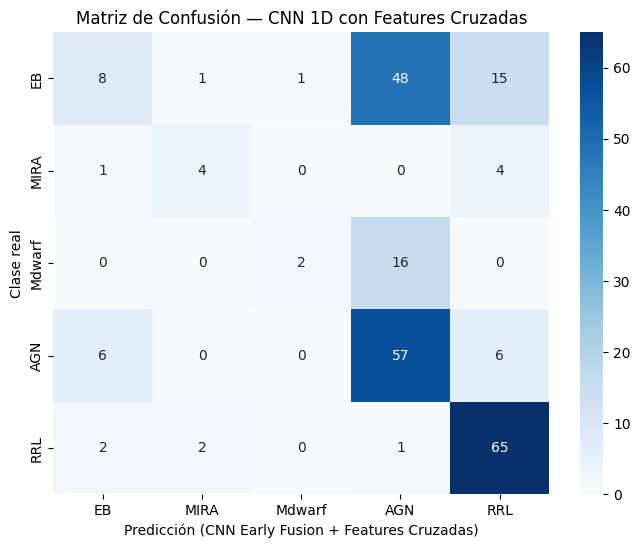

In [ ]:
# ============================================================
# CNN 1D con early fusion + features cruzadas entre bandas
# ============================================================
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1) Codificar y en 0..K-1
le_cross = LabelEncoder()
y_train_cross_enc = le_cross.fit_transform(y_train_cross)
y_valid_cross_enc = le_cross.transform(y_valid_cross)
num_classes_cross = len(le_cross.classes_)
print("Clases (encoder cross):", le_cross.classes_)

# 2) Preparar X para CNN: (n_samples, n_features, 1)
n_features_cross = X_train_cross_sc.shape[1]
X_train_cnn_cross = X_train_cross_sc.reshape(-1, n_features_cross, 1)
X_valid_cnn_cross = X_valid_cross_sc.reshape(-1, n_features_cross, 1)

print("Shape X_train_cnn_cross:", X_train_cnn_cross.shape)
print("Shape X_valid_cnn_cross:", X_valid_cnn_cross.shape)

# 3) Pesos de clase
class_weights_array_cross = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_cross_enc),
    y=y_train_cross_enc
)
class_weight_cross = {i: w for i, w in enumerate(class_weights_array_cross)}
print("Pesos de clase (CNN cross):", class_weight_cross)

# 4) Definir modelo CNN 1D
model_cross = models.Sequential([
    layers.Input(shape=(n_features_cross, 1)),
    layers.Conv1D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes_cross, activation="softmax")
])

model_cross.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

es_cross = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# 5) Entrenamiento
history_cross = model_cross.fit(
    X_train_cnn_cross, y_train_cross_enc,
    epochs=200,
    batch_size=32,
    validation_data=(X_valid_cnn_cross, y_valid_cross_enc),
    callbacks=[es_cross],
    class_weight=class_weight_cross,
    verbose=1
)

# 6) Evaluación
train_loss_cross, train_acc_cross = model_cross.evaluate(X_train_cnn_cross, y_train_cross_enc, verbose=0)
valid_loss_cross, valid_acc_cross = model_cross.evaluate(X_valid_cnn_cross, y_valid_cross_enc, verbose=0)

print("\n=== CNN 1D (early fusion + features cruzadas): Accuracy ===")
print(f"Train      : {train_acc_cross:.4f}")
print(f"Validación : {valid_acc_cross:.4f}")

# 7) Métricas adicionales
y_pred_prob_cross = model_cross.predict(X_valid_cnn_cross, verbose=0)
y_pred_cross_enc  = np.argmax(y_pred_prob_cross, axis=1)

f1m_cross  = f1_score(y_valid_cross_enc, y_pred_cross_enc, average="macro")
balc_cross = balanced_accuracy_score(y_valid_cross_enc, y_pred_cross_enc)

print("\n=== CNN 1D (early fusion + features cruzadas): Métricas ===")
print(f"F1-macro          : {f1m_cross:.4f}")
print(f"Balanced accuracy : {balc_cross:.4f}")
# ============================================================
# Matriz de Confusión — CNN 1D Early Fusion + Features Cruzadas
# ============================================================
from sklearn.metrics import confusion_matrix

# Si no existe label_map en esta celda, lo creamos:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Orden de clases en el espacio original (targets numéricos)
class_targets_cross = list(le_cross.classes_)              # mismos targets que vio el encoder
class_names_cross   = [label_map[t] for t in class_targets_cross]

# En el espacio codificado, las clases son 0..K-1
labels_enc_cross = np.arange(num_classes_cross)

cm_cnn_cross = confusion_matrix(
    y_valid_cross_enc,
    y_pred_cross_enc,
    labels=labels_enc_cross
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn_cross, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_cross,
            yticklabels=class_names_cross)
plt.xlabel("Predicción (CNN Early Fusion + Features Cruzadas)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión — CNN 1D con Features Cruzadas")
plt.show()


Clases GMM cross fusion: [16 53 65 88 92]
Entrenando GMM cross: clase 0 (16), n=171
Entrenando GMM cross: clase 1 (53), n=21
Entrenando GMM cross: clase 2 (65), n=41
Entrenando GMM cross: clase 3 (88), n=161
Entrenando GMM cross: clase 4 (92), n=162

=== GMM (early fusion + features cruzadas) ===
Accuracy          : 0.8075
F1-macro          : 0.8212
Balanced accuracy : 0.8049


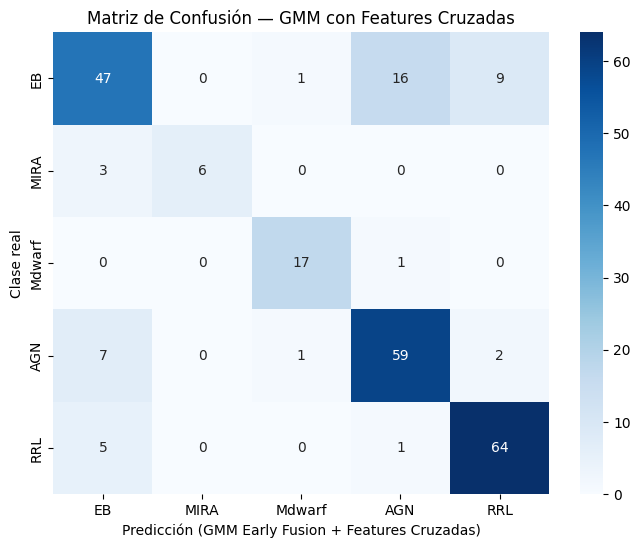

In [ ]:
# ============================================================
# GMM con early fusion + features cruzadas
# ============================================================
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from scipy.special import logsumexp

# Asegurar arrays puros
if hasattr(X_train_cross_sc, "values"):
    X_train_gmm_cross = X_train_cross_sc.values
else:
    X_train_gmm_cross = X_train_cross_sc

if hasattr(X_valid_cross_sc, "values"):
    X_valid_gmm_cross = X_valid_cross_sc.values
else:
    X_valid_gmm_cross = X_valid_cross_sc

# 1) Codificar y en 0..K-1
le_gmm_cross = LabelEncoder()
y_train_cross_enc = le_gmm_cross.fit_transform(y_train_cross)
y_valid_cross_enc = le_gmm_cross.transform(y_valid_cross)
classes_enc = np.arange(len(le_gmm_cross.classes_))
n_classes = len(classes_enc)

print("Clases GMM cross fusion:", le_gmm_cross.classes_)

# 2) Entrenar un GMM por clase (1 componente)
gmm_models_cross = {}
for c in classes_enc:
    mask_c = (y_train_cross_enc == c)
    Xc = X_train_gmm_cross[mask_c]

    print(f"Entrenando GMM cross: clase {c} ({le_gmm_cross.classes_[c]}), n={Xc.shape[0]}")

    gmm = GaussianMixture(
        n_components=1,
        covariance_type="full",
        reg_covar=1e-6,
        random_state=42
    )
    gmm.fit(Xc)
    gmm_models_cross[c] = gmm

log_prior = -np.log(n_classes)

# 3) Función para obtener p(clase|x)
def gmm_proba_cross(X):
    log_probs = np.zeros((X.shape[0], n_classes))
    for idx, c in enumerate(classes_enc):
        gmm = gmm_models_cross[c]
        log_probs[:, idx] = gmm.score_samples(X) + log_prior

    # Normalizar (log-softmax)
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    probs = np.exp(log_probs - log_norm)
    return probs

# 4) Predicciones
proba_valid_cross = gmm_proba_cross(X_valid_gmm_cross)
y_pred_cross_enc = np.argmax(proba_valid_cross, axis=1)

# 5) Métricas
acc_cross  = accuracy_score(y_valid_cross_enc, y_pred_cross_enc)
f1m_cross  = f1_score(y_valid_cross_enc, y_pred_cross_enc, average="macro")
balc_cross = balanced_accuracy_score(y_valid_cross_enc, y_pred_cross_enc)

print("\n=== GMM (early fusion + features cruzadas) ===")
print(f"Accuracy          : {acc_cross:.4f}")
print(f"F1-macro          : {f1m_cross:.4f}")
print(f"Balanced accuracy : {balc_cross:.4f}")

# ============================================================
# Matriz de Confusión — GMM Early Fusion + Features Cruzadas
# ============================================================

from sklearn.metrics import confusion_matrix

# Si no existe label_map en esta celda, lo creamos:
label_map = (
    dataset[["target", "type"]]
    .drop_duplicates()
    .set_index("target")["type"]
    .to_dict()
)

# Orden de clases en el espacio original (targets numéricos reales)
class_targets_cross = list(le_gmm_cross.classes_)
class_names_cross   = [label_map[t] for t in class_targets_cross]

# Clases en el espacio codificado del encoder (0..K-1)
labels_enc_cross = np.arange(n_classes)

# Matriz de confusión
cm_gmm_cross = confusion_matrix(
    y_valid_cross_enc,
    y_pred_cross_enc,
    labels=labels_enc_cross
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gmm_cross, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_cross,
            yticklabels=class_names_cross)
plt.xlabel("Predicción (GMM Early Fusion + Features Cruzadas)")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión — GMM con Features Cruzadas")
plt.show()

